# Visualización de Señales de Trading
Esta celda contiene funciones para generar gráficos interactivos con señales de entrada y salida superpuestas sobre las velas japonesas.

In [1]:
def create_trading_chart_with_signals(data, signals=None, title="Trading Chart"):
    """
    Genera un gráfico de velas japonesas con señales de trading superpuestas
    
    Parameters:
    data: DataFrame con columnas OHLCV
    signals: Lista de diccionarios con señales [{time, price, signal_type, probability}]
    title: Título del gráfico
    """
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    
    # Crear subplots (precio + volumen)
    fig = make_subplots(
        rows=2, cols=1,
        shared_xaxes=True,
        row_heights=[0.7, 0.3],
        subplot_titles=('Precio', 'Volumen'),
        vertical_spacing=0.05
    )
    
    # Agregar velas japonesas
    fig.add_trace(
        go.Candlestick(
            x=data.index,
            open=data['Open'],
            high=data['High'],
            low=data['Low'],
            close=data['Close'],
            name='Precio',
            increasing_line_color='#00FF00',
            decreasing_line_color='#FF0000'
        ),
        row=1, col=1
    )
    
    # Agregar EMAs si están disponibles
    if 'EMA_9' in data.columns:
        fig.add_trace(
            go.Scatter(x=data.index, y=data['EMA_9'], 
                      name='EMA 9', line=dict(color='orange', width=1)),
            row=1, col=1
        )
    
    if 'EMA_21' in data.columns:
        fig.add_trace(
            go.Scatter(x=data.index, y=data['EMA_21'], 
                      name='EMA 21', line=dict(color='blue', width=1)),
            row=1, col=1
        )
    
    # Agregar señales de trading
    if signals:
        buy_signals = [s for s in signals if s.get('signal_type') in ['BUY', 'LONG', 'ENTRY_LONG']]
        sell_signals = [s for s in signals if s.get('signal_type') in ['SELL', 'SHORT', 'ENTRY_SHORT']]
        
        # Señales de compra
        if buy_signals:
            buy_times = [s['time'] for s in buy_signals]
            buy_prices = [s['price'] for s in buy_signals]
            buy_probs = [s.get('probability', 0) for s in buy_signals]
            
            fig.add_trace(
                go.Scatter(
                    x=buy_times,
                    y=buy_prices,
                    mode='markers',
                    marker=dict(
                        symbol='triangle-up',
                        size=12,
                        color='green',
                        line=dict(width=2, color='darkgreen')
                    ),
                    name='Señal Compra',
                    text=[f'Prob: {p:.1%}' for p in buy_probs],
                    hovertemplate='<b>COMPRA</b><br>' +
                                 'Precio: %{y}<br>' +
                                 'Tiempo: %{x}<br>' +
                                 '%{text}<extra></extra>'
                ),
                row=1, col=1
            )
        
        # Señales de venta
        if sell_signals:
            sell_times = [s['time'] for s in sell_signals]
            sell_prices = [s['price'] for s in sell_signals]
            sell_probs = [s.get('probability', 0) for s in sell_signals]
            
            fig.add_trace(
                go.Scatter(
                    x=sell_times,
                    y=sell_prices,
                    mode='markers',
                    marker=dict(
                        symbol='triangle-down',
                        size=12,
                        color='red',
                        line=dict(width=2, color='darkred')
                    ),
                    name='Señal Venta',
                    text=[f'Prob: {p:.1%}' for p in sell_probs],
                    hovertemplate='<b>VENTA</b><br>' +
                                 'Precio: %{y}<br>' +
                                 'Tiempo: %{x}<br>' +
                                 '%{text}<extra></extra>'
                ),
                row=1, col=1
            )
    
    # Agregar volumen
    if 'Volume' in data.columns:
        colors = ['green' if close >= open else 'red' 
                 for close, open in zip(data['Close'], data['Open'])]
        
        fig.add_trace(
            go.Bar(
                x=data.index,
                y=data['Volume'],
                name='Volumen',
                marker_color=colors,
                opacity=0.6
            ),
            row=2, col=1
        )
    
    # Configurar layout
    fig.update_layout(
        title=dict(text=title, x=0.5, font=dict(size=16)),
        xaxis_rangeslider_visible=False,
        height=800,
        showlegend=True,
        hovermode='x unified'
    )
    
    # Configurar ejes
    fig.update_xaxes(title_text="Tiempo", row=2, col=1)
    fig.update_yaxes(title_text="Precio", row=1, col=1)
    fig.update_yaxes(title_text="Volumen", row=2, col=1)
    
    return fig

def generate_signals_from_data(data, predictor=None):
    """
    Genera señales de trading basadas en el análisis ICT y predictor ML
    
    Parameters:
    data: DataFrame con datos OHLCV
    predictor: Modelo predictivo entrenado (opcional)
    
    Returns:
    Lista de señales con formato [{time, price, signal_type, probability}]
    """
    signals = []
    
    # Detectar patrones ICT
    data_with_patterns = detect_sweeps(data.copy(), lookback=3)
    data_with_patterns = detect_fvg(data_with_patterns)
    
    # Generar señales basadas en patrones
    for i in range(len(data_with_patterns)):
        row = data_with_patterns.iloc[i]
        current_time = data_with_patterns.index[i]
        current_price = row['Close']
        
        # Señal de sweep up (bearish)
        if row.get('SweepUp', False):
            probability = 0.6  # Probabilidad base
            if predictor:
                try:
                    subset = data.iloc[:i+1]
                    if len(subset) >= getattr(predictor, 'lookback', 10):
                        probability = predictor.get_signal_strength(subset, i)
                except:
                    pass
            
            signals.append({
                'time': current_time,
                'price': current_price,
                'signal_type': 'ENTRY_SHORT',
                'probability': probability,
                'pattern': 'Sweep Up'
            })
        
        # Señal de sweep down (bullish)  
        if row.get('SweepDown', False):
            probability = 0.6  # Probabilidad base
            if predictor:
                try:
                    subset = data.iloc[:i+1]
                    if len(subset) >= getattr(predictor, 'lookback', 10):
                        probability = predictor.get_signal_strength(subset, i)
                except:
                    pass
            
            signals.append({
                'time': current_time,
                'price': current_price,
                'signal_type': 'ENTRY_LONG',
                'probability': probability,
                'pattern': 'Sweep Down'
            })
        
        # Señal de FVG
        if row.get('FVG_Up', False):
            signals.append({
                'time': current_time,
                'price': current_price,
                'signal_type': 'ENTRY_LONG',
                'probability': 0.5,
                'pattern': 'FVG Up'
            })
        
        if row.get('FVG_Dn', False):
            signals.append({
                'time': current_time,
                'price': current_price,
                'signal_type': 'ENTRY_SHORT', 
                'probability': 0.5,
                'pattern': 'FVG Down'
            })
    
    return signals

print("✅ Funciones de visualización con señales cargadas correctamente")

✅ Funciones de visualización con señales cargadas correctamente


# Funciones de Detección de Patrones ICT
Implementación de las funciones para detectar sweeps, FVGs y otros patrones ICT en los datos de trading.

In [2]:
def detect_sweeps(data, lookback=3, min_strength=0.1):
    """
    Detecta sweeps (barridos) de liquidez en los datos
    
    Parameters:
    data: DataFrame con columnas OHLC
    lookback: Número de períodos para detectar swing highs/lows
    min_strength: Mínima diferencia porcentual para considerar un sweep
    
    Returns:
    DataFrame original con columnas adicionales: SwingHigh, SwingLow, SweepUp, SweepDown
    """
    df = data.copy()
    df['SwingHigh'] = False
    df['SwingLow'] = False
    df['SweepUp'] = False
    df['SweepDown'] = False
    
    # Detectar swing highs y lows
    for i in range(lookback, len(df) - lookback):
        current_high = df['High'].iloc[i]
        current_low = df['Low'].iloc[i]
        
        # Swing High: máximo local
        is_swing_high = True
        for j in range(i - lookback, i + lookback + 1):
            if j != i and df['High'].iloc[j] >= current_high:
                is_swing_high = False
                break
        
        if is_swing_high:
            df.iloc[i, df.columns.get_loc('SwingHigh')] = True
        
        # Swing Low: mínimo local  
        is_swing_low = True
        for j in range(i - lookback, i + lookback + 1):
            if j != i and df['Low'].iloc[j] <= current_low:
                is_swing_low = False
                break
        
        if is_swing_low:
            df.iloc[i, df.columns.get_loc('SwingLow')] = True
    
    # Detectar sweeps (barridos)
    swing_highs = df[df['SwingHigh']]['High'].to_dict()
    swing_lows = df[df['SwingLow']]['Low'].to_dict()
    
    for i in range(len(df)):
        current_high = df['High'].iloc[i]
        current_low = df['Low'].iloc[i]
        current_time = df.index[i]
        
        # Sweep Up: precio supera un swing high reciente pero luego retrocede
        for swing_time, swing_high in swing_highs.items():
            if (swing_time < current_time and 
                current_high > swing_high * (1 + min_strength/100) and
                i > 0 and df['Close'].iloc[i] < df['Close'].iloc[i-1]):
                df.iloc[i, df.columns.get_loc('SweepUp')] = True
                break
        
        # Sweep Down: precio rompe un swing low reciente pero luego retrocede
        for swing_time, swing_low in swing_lows.items():
            if (swing_time < current_time and 
                current_low < swing_low * (1 - min_strength/100) and
                i > 0 and df['Close'].iloc[i] > df['Close'].iloc[i-1]):
                df.iloc[i, df.columns.get_loc('SweepDown')] = True
                break
    
    return df

def detect_fvg(data, min_gap_percentage=0.05):
    """
    Detecta Fair Value Gaps (FVGs) en los datos
    
    Parameters:
    data: DataFrame con columnas OHLC
    min_gap_percentage: Mínimo porcentaje de gap para considerar un FVG
    
    Returns:
    DataFrame original con columnas adicionales: FVG_Up, FVG_Dn
    """
    df = data.copy()
    df['FVG_Up'] = False
    df['FVG_Dn'] = False
    
    for i in range(2, len(df)):
        # FVG Alcista: gap entre vela i-2 y vela i
        prev_high = df['High'].iloc[i-2]
        curr_low = df['Low'].iloc[i]
        
        if curr_low > prev_high:
            gap_percentage = ((curr_low / prev_high) - 1) * 100
            if gap_percentage >= min_gap_percentage:
                df.iloc[i-1, df.columns.get_loc('FVG_Up')] = True
        
        # FVG Bajista: gap entre vela i-2 y vela i
        prev_low = df['Low'].iloc[i-2]
        curr_high = df['High'].iloc[i]
        
        if curr_high < prev_low:
            gap_percentage = ((prev_low / curr_high) - 1) * 100
            if gap_percentage >= min_gap_percentage:
                df.iloc[i-1, df.columns.get_loc('FVG_Dn')] = True
    
    return df

def detect_market_structure_shift(data, lookback=5):
    """
    Detecta cambios en la estructura de mercado (MSS)
    
    Parameters:
    data: DataFrame con columnas OHLC
    lookback: Número de períodos para evaluar la estructura
    
    Returns:
    DataFrame con columna adicional: MSS (Market Structure Shift)
    """
    df = data.copy()
    df['MSS'] = False
    
    # Detectar MSS basado en quiebre de estructura de higher highs/lower lows
    for i in range(lookback, len(df)):
        recent_highs = df['High'].iloc[i-lookback:i+1]
        recent_lows = df['Low'].iloc[i-lookback:i+1]
        
        # MSS Bajista: quiebre de higher lows
        if (recent_lows.iloc[-1] < recent_lows.iloc[-2] and 
            recent_lows.iloc[-2] < recent_lows.iloc[-3]):
            df.iloc[i, df.columns.get_loc('MSS')] = True
        
        # MSS Alcista: quiebre de lower highs  
        if (recent_highs.iloc[-1] > recent_highs.iloc[-2] and 
            recent_highs.iloc[-2] > recent_highs.iloc[-3]):
            df.iloc[i, df.columns.get_loc('MSS')] = True
    
    return df

def analyze_killzones(data, killzones_config):
    """
    Analiza la actividad durante las killzones
    
    Parameters:
    data: DataFrame con datos OHLC indexado por tiempo
    killzones_config: Lista de tuplas (nombre, hora_inicio, hora_fin)
    
    Returns:
    DataFrame con columna adicional: Killzone
    """
    df = data.copy()
    df['Killzone'] = 'None'
    
    for index, row in df.iterrows():
        hour = index.hour
        minute = index.minute
        current_time_minutes = hour * 60 + minute
        
        for kz_name, (start_h, start_m), (end_h, end_m) in killzones_config:
            start_minutes = start_h * 60 + start_m
            end_minutes = end_h * 60 + end_m
            
            if start_minutes <= current_time_minutes <= end_minutes:
                df.loc[index, 'Killzone'] = kz_name
                break
    
    return df

# Configuración por defecto de killzones
DEFAULT_KILLZONES = [
    ('London', (8, 0), (11, 0)),
    ('NY_AM', (13, 0), (16, 0)),
    ('Asian', (20, 0), (23, 0))
]

print("✅ Funciones de detección de patrones ICT cargadas correctamente")

✅ Funciones de detección de patrones ICT cargadas correctamente


# Ejecución de Gráfico con Señales
Esta celda ejecuta la visualización del gráfico de velas japonesas con las señales de trading detectadas superpuestas.

In [3]:
# === GENERAR GRÁFICO CON SEÑALES DE TRADING ===

# Importar librerías necesarias
import pytz
from datetime import datetime
import pandas as pd
import MetaTrader5 as mt5

# Configuración
SYMBOL = 'EURUSD'
TIMEFRAME = mt5.TIMEFRAME_M5
LOCAL_TZ = "America/New_York"

# Inicializar MT5 si no está inicializado
if not mt5.initialize():
    print("Error al inicializar MT5")
    mt5.shutdown()
else:
    print("✅ MT5 inicializado correctamente")

# Obtener datos del día actual desde MT5
def get_daily_data_with_emas():
    """Obtiene datos diarios y calcula EMAs"""
    print("📊 Descargando datos desde MT5...")
    
    # Establecer timezone y obtener datos del día actual
    timezone = pytz.timezone(LOCAL_TZ)
    now = datetime.now(timezone)
    start_of_day = now.replace(hour=0, minute=0, second=0, microsecond=0)
    end_of_day = now.replace(hour=23, minute=59, second=59)
    
    # Obtener datos desde MT5
    rates = mt5.copy_rates_range(SYMBOL, TIMEFRAME, start_of_day, end_of_day)
    
    if rates is None or len(rates) == 0:
        print("❌ No se pudieron obtener datos de MT5")
        return None
    
    # Convertir a DataFrame
    df = pd.DataFrame(rates)
    df['time'] = pd.to_datetime(df['time'], unit='s')
    df.set_index('time', inplace=True)
    
    # Renombrar columnas para compatibilidad
    df.rename(columns={
        'open': 'Open',
        'high': 'High', 
        'low': 'Low',
        'close': 'Close',
        'tick_volume': 'Volume'
    }, inplace=True)
    
    # Calcular EMAs
    df['EMA_9'] = df['Close'].ewm(span=9).mean()
    df['EMA_21'] = df['Close'].ewm(span=21).mean()
    df['EMA_50'] = df['Close'].ewm(span=50).mean()
    
    print(f"✅ {len(df)} velas obtenidas de {SYMBOL}")
    return df

# Obtener datos actuales
current_data = get_daily_data_with_emas()

if current_data is not None and len(current_data) > 0:
    print(f"\n🔍 Generando señales de trading...")
    
    # Generar señales usando el predictor si está disponible
    predictor_model = globals().get('predictor', None)
    trading_signals = generate_signals_from_data(current_data, predictor_model)
    
    print(f"🎯 Señales detectadas: {len(trading_signals)}")
    
    # Mostrar resumen de señales
    if trading_signals:
        buy_signals = [s for s in trading_signals if 'LONG' in s['signal_type']]
        sell_signals = [s for s in trading_signals if 'SHORT' in s['signal_type']]
        
        print(f"📈 Señales de compra: {len(buy_signals)}")
        print(f"📉 Señales de venta: {len(sell_signals)}")
        
        # Mostrar las 3 señales con mayor probabilidad
        top_signals = sorted(trading_signals, key=lambda x: x['probability'], reverse=True)[:3]
        print(f"\n🏆 TOP 3 SEÑALES:")
        for i, signal in enumerate(top_signals, 1):
            signal_type = "🟢 LONG" if "LONG" in signal['signal_type'] else "🔴 SHORT"
            print(f"{i}. {signal['time'].strftime('%H:%M')} - {signal_type} @ {signal['price']:.5f} - {signal['probability']:.1%} ({signal['pattern']})")
    
    # Crear y mostrar el gráfico interactivo
    print(f"\n📊 Generando gráfico interactivo...")
    
    chart_title = f"{SYMBOL} - Señales de Trading ICT - {datetime.now().strftime('%Y-%m-%d')}"
    fig = create_trading_chart_with_signals(current_data, trading_signals, chart_title)
    
    # Agregar killzones como zonas sombreadas
    london_start = current_data.index[0].replace(hour=8, minute=0)
    london_end = current_data.index[0].replace(hour=11, minute=0)
    ny_start = current_data.index[0].replace(hour=13, minute=0)
    ny_end = current_data.index[0].replace(hour=16, minute=0)
    
    # Agregar zonas de killzones
    fig.add_vrect(
        x0=london_start, x1=london_end,
        fillcolor="rgba(255,255,0,0.1)",
        layer="below", line_width=0,
        annotation_text="London KZ", annotation_position="top left"
    )
    
    fig.add_vrect(
        x0=ny_start, x1=ny_end,
        fillcolor="rgba(0,255,255,0.1)", 
        layer="below", line_width=0,
        annotation_text="NY KZ", annotation_position="top left"
    )
    
    # Mostrar el gráfico
    fig.show()
    
    print(f"\n✅ Gráfico con señales generado exitosamente")
    
    # Estadísticas adicionales
    if len(current_data) > 0:
        price_change = ((current_data['Close'].iloc[-1] / current_data['Close'].iloc[0]) - 1) * 100
        daily_range = ((current_data['High'].max() / current_data['Low'].min()) - 1) * 100
        
        print(f"\n📊 ESTADÍSTICAS DEL DÍA:")
        print(f"💹 Cambio de precio: {price_change:+.2f}%")
        print(f"📏 Rango diario: {daily_range:.2f}%")
        print(f"📈 Precio actual: {current_data['Close'].iloc[-1]:.5f}")
        print(f"🔆 Máximo del día: {current_data['High'].max():.5f}")
        print(f"🔅 Mínimo del día: {current_data['Low'].min():.5f}")

else:
    print("❌ No se pudieron obtener datos para generar el gráfico")

✅ MT5 inicializado correctamente
📊 Descargando datos desde MT5...
✅ 135 velas obtenidas de EURUSD

🔍 Generando señales de trading...
🎯 Señales detectadas: 37
📈 Señales de compra: 37
📉 Señales de venta: 0

🏆 TOP 3 SEÑALES:
1. 08:15 - 🟢 LONG @ 1.16915 - 60.0% (Sweep Down)
2. 08:30 - 🟢 LONG @ 1.16896 - 60.0% (Sweep Down)
3. 08:40 - 🟢 LONG @ 1.16898 - 60.0% (Sweep Down)

📊 Generando gráfico interactivo...
✅ 135 velas obtenidas de EURUSD

🔍 Generando señales de trading...
🎯 Señales detectadas: 37
📈 Señales de compra: 37
📉 Señales de venta: 0

🏆 TOP 3 SEÑALES:
1. 08:15 - 🟢 LONG @ 1.16915 - 60.0% (Sweep Down)
2. 08:30 - 🟢 LONG @ 1.16896 - 60.0% (Sweep Down)
3. 08:40 - 🟢 LONG @ 1.16898 - 60.0% (Sweep Down)

📊 Generando gráfico interactivo...



✅ Gráfico con señales generado exitosamente

📊 ESTADÍSTICAS DEL DÍA:
💹 Cambio de precio: -0.34%
📏 Rango diario: 0.47%
📈 Precio actual: 1.16637
🔆 Máximo del día: 1.17083
🔅 Mínimo del día: 1.16533


# Análisis Paso a Paso - Vela por Vela
Esta sección permite analizar la evolución de las predicciones vela por vela, viendo cómo cambian los patrones ICT y las señales en tiempo real.

In [4]:
# === ANALIZADOR PASO A PASO ===

class StepByStepAnalyzer:
    """Analizador que permite revisar vela por vela la evolución de predicciones"""
    
    def __init__(self, data, predictor=None):
        self.data = data.copy()
        self.predictor = predictor
        self.current_index = 20  # Empezar después del lookback mínimo
        self.max_index = len(data) - 1
        self.history = []
        
        print(f"🔍 Analizador inicializado")
        print(f"📊 Total de velas: {len(self.data)}")
        print(f"⏩ Vela actual: {self.current_index + 1}")
        print(f"⏰ Período: {self.data.index[0].strftime('%Y-%m-%d %H:%M')} - {self.data.index[-1].strftime('%Y-%m-%d %H:%M')}")
    
    def get_current_subset(self):
        """Obtiene el subset de datos hasta la vela actual"""
        return self.data.iloc[:self.current_index + 1].copy()
    
    def analyze_current_candle(self):
        """Analiza la vela actual y genera predicciones"""
        if self.current_index > self.max_index:
            print("❌ Ya llegaste al final de los datos")
            return None
            
        # Obtener datos hasta la vela actual
        current_data = self.get_current_subset()
        current_candle = current_data.iloc[-1]
        current_time = current_data.index[-1]
        
        # Información básica de la vela
        analysis = {
            'index': self.current_index,
            'time': current_time,
            'candle': {
                'open': current_candle['Open'],
                'high': current_candle['High'], 
                'low': current_candle['Low'],
                'close': current_candle['Close'],
                'volume': current_candle['Volume']
            }
        }
        
        # Detectar patrones ICT en los datos actuales
        try:
            # Detectar sweeps
            data_with_sweeps = detect_sweeps(current_data.copy(), lookback=3)
            current_sweep = data_with_sweeps.iloc[-1]
            
            analysis['patterns'] = {
                'sweep_up': bool(current_sweep.get('SweepUp', False)),
                'sweep_down': bool(current_sweep.get('SweepDown', False)),
                'fake_breakout_up': bool(current_sweep.get('FakeBreakoutUp', False)),
                'fake_breakout_down': bool(current_sweep.get('FakeBreakoutDown', False))
            }
            
            # Detectar FVG
            data_with_fvg = detect_fvg(current_data.copy())
            if len(data_with_fvg) > 1:
                current_fvg = data_with_fvg.iloc[-1]
                analysis['patterns']['fvg_bullish'] = bool(current_fvg.get('FVG_Bullish', False))
                analysis['patterns']['fvg_bearish'] = bool(current_fvg.get('FVG_Bearish', False))
            
        except Exception as e:
            print(f"⚠️  Error en detección de patrones: {e}")
            analysis['patterns'] = {}
        
        # Generar señales si hay patrones
        signals = []
        if analysis['patterns']:
            try:
                signals = generate_signals_from_data(current_data, self.predictor)
                current_signals = [s for s in signals if s['time'] == current_time]
                analysis['signals'] = current_signals
            except Exception as e:
                print(f"⚠️  Error en generación de señales: {e}")
                analysis['signals'] = []
        else:
            analysis['signals'] = []
        
        # Calcular predicción si hay predictor
        if self.predictor and len(current_data) >= self.predictor.lookback:
            try:
                # Obtener la predicción del predictor
                prediction_strength = self.predictor.get_signal_strength(current_data, self.current_index)
                analysis['prediction'] = {
                    'strength': prediction_strength,
                    'direction': 'BULLISH' if prediction_strength > 0.5 else 'BEARISH',
                    'confidence': abs(prediction_strength - 0.5) * 2
                }
            except Exception as e:
                print(f"⚠️  Error en predicción: {e}")
                analysis['prediction'] = None
        else:
            analysis['prediction'] = None
            
        # Guardar en historial
        self.history.append(analysis)
        
        return analysis
    
    def print_analysis(self, analysis):
        """Imprime el analysis de forma legible"""
        if not analysis:
            return
            
        print(f"\n{'='*60}")
        print(f"📊 VELA #{analysis['index'] + 1} - {analysis['time'].strftime('%Y-%m-%d %H:%M')}")
        print(f"{'='*60}")
        
        # Información de la vela
        candle = analysis['candle']
        candle_type = "🟢 BULLISH" if candle['close'] > candle['open'] else "🔴 BEARISH"
        body_size = abs(candle['close'] - candle['open'])
        wick_high = candle['high'] - max(candle['open'], candle['close'])
        wick_low = min(candle['open'], candle['close']) - candle['low']
        
        print(f"💹 OHLC: {candle['open']:.5f} | {candle['high']:.5f} | {candle['low']:.5f} | {candle['close']:.5f}")
        print(f"📈 Tipo: {candle_type} | Cuerpo: {body_size:.5f} | Vol: {candle['volume']}")
        print(f"🕯️  Mechas: Superior {wick_high:.5f} | Inferior {wick_low:.5f}")
        
        # Patrones ICT detectados
        patterns = analysis.get('patterns', {})
        if any(patterns.values()):
            print(f"\n🎯 PATRONES ICT DETECTADOS:")
            if patterns.get('sweep_up'): print("   🔸 Sweep Up (Bearish)")
            if patterns.get('sweep_down'): print("   🔸 Sweep Down (Bullish)")  
            if patterns.get('fake_breakout_up'): print("   🔸 Fake Breakout Up")
            if patterns.get('fake_breakout_down'): print("   🔸 Fake Breakout Down")
            if patterns.get('fvg_bullish'): print("   🔸 FVG Bullish")
            if patterns.get('fvg_bearish'): print("   🔸 FVG Bearish")
        else:
            print(f"\n⚪ No se detectaron patrones ICT")
        
        # Señales generadas
        signals = analysis.get('signals', [])
        if signals:
            print(f"\n🚨 SEÑALES GENERADAS ({len(signals)}):")
            for signal in signals:
                signal_type = "🟢 LONG" if "LONG" in signal['signal_type'] else "🔴 SHORT"
                print(f"   {signal_type} @ {signal['price']:.5f} - {signal['probability']:.1%} ({signal['pattern']})")
        else:
            print(f"\n⚪ No se generaron señales")
            
        # Predicción del modelo
        prediction = analysis.get('prediction')
        if prediction:
            direction_emoji = "🔼" if prediction['direction'] == 'BULLISH' else "🔽"
            print(f"\n🤖 PREDICCIÓN DEL MODELO:")
            print(f"   {direction_emoji} {prediction['direction']} - Fuerza: {prediction['strength']:.3f}")
            print(f"   🎯 Confianza: {prediction['confidence']:.1%}")
        else:
            print(f"\n⚪ Sin predicción del modelo")
    
    def next_candle(self):
        """Avanza a la siguiente vela"""
        if self.current_index >= self.max_index:
            print("❌ Ya llegaste al final de los datos")
            return None
            
        self.current_index += 1
        analysis = self.analyze_current_candle()
        self.print_analysis(analysis)
        return analysis
    
    def previous_candle(self):
        """Retrocede a la vela anterior"""
        if self.current_index <= 20:
            print("❌ Ya llegaste al inicio (mínimo lookback)")
            return None
            
        self.current_index -= 1
        # Recalcular analysis para la vela anterior
        analysis = self.analyze_current_candle()
        self.print_analysis(analysis)
        return analysis
    
    def jump_to_candle(self, index):
        """Salta a una vela específica"""
        if index < 20:
            print("❌ Índice muy bajo (mínimo 20)")
            return None
        if index > self.max_index:
            print(f"❌ Índice muy alto (máximo {self.max_index})")
            return None
            
        self.current_index = index
        analysis = self.analyze_current_candle()
        self.print_analysis(analysis)
        return analysis
    
    def show_summary(self):
        """Muestra un resumen del análisis hasta ahora"""
        if not self.history:
            print("❌ No hay historial de análisis")
            return
            
        print(f"\n{'='*60}")
        print(f"📋 RESUMEN DE ANÁLISIS - {len(self.history)} velas analizadas")
        print(f"{'='*60}")
        
        # Contar patrones
        patterns_count = {
            'sweep_up': 0, 'sweep_down': 0,
            'fake_breakout_up': 0, 'fake_breakout_down': 0,
            'fvg_bullish': 0, 'fvg_bearish': 0
        }
        
        signals_count = {'LONG': 0, 'SHORT': 0}
        predictions_count = {'BULLISH': 0, 'BEARISH': 0}
        
        for analysis in self.history:
            # Contar patrones
            for pattern, value in analysis.get('patterns', {}).items():
                if value and pattern in patterns_count:
                    patterns_count[pattern] += 1
            
            # Contar señales
            for signal in analysis.get('signals', []):
                if 'LONG' in signal['signal_type']:
                    signals_count['LONG'] += 1
                else:
                    signals_count['SHORT'] += 1
            
            # Contar predicciones
            prediction = analysis.get('prediction')
            if prediction:
                predictions_count[prediction['direction']] += 1
        
        print(f"🎯 PATRONES DETECTADOS:")
        for pattern, count in patterns_count.items():
            if count > 0:
                print(f"   {pattern.replace('_', ' ').title()}: {count}")
        
        print(f"\n🚨 SEÑALES GENERADAS:")
        print(f"   🟢 LONG: {signals_count['LONG']}")
        print(f"   🔴 SHORT: {signals_count['SHORT']}")
        
        if predictions_count['BULLISH'] + predictions_count['BEARISH'] > 0:
            print(f"\n🤖 PREDICCIONES:")
            print(f"   🔼 BULLISH: {predictions_count['BULLISH']}")
            print(f"   🔽 BEARISH: {predictions_count['BEARISH']}")

print("✅ Analizador paso a paso cargado correctamente")

✅ Analizador paso a paso cargado correctamente


In [5]:
# === INICIALIZAR ANALIZADOR PASO A PASO ===

# Verificar que todas las dependencias estén disponibles
print("🔍 Verificando dependencias...")

# Verificar si la clase SweepMSSFVGPredictor está definida
if 'SweepMSSFVGPredictor' not in globals():
    print("❌ ERROR: La clase SweepMSSFVGPredictor no está definida")
    print("📋 SOLUCIÓN: Ejecuta primero la celda 'Definición del predictor'")
    print("   (Busca la celda con 'class SweepMSSFVGPredictor' y ejecútala)")
else:
    print("✅ SweepMSSFVGPredictor encontrado")

# Verificar funciones necesarias
required_functions = ['get_daily_data_with_emas', 'detect_sweeps', 'detect_fvg', 'generate_signals_from_data', 'StepByStepAnalyzer']
missing_functions = []

for func_name in required_functions:
    if func_name not in globals():
        missing_functions.append(func_name)

if missing_functions:
    print(f"❌ ERROR: Faltan funciones: {', '.join(missing_functions)}")
    print("📋 SOLUCIÓN: Ejecuta todas las celdas anteriores en orden")
else:
    print("✅ Todas las funciones necesarias encontradas")

# Solo continuar si todo está disponible
if 'SweepMSSFVGPredictor' in globals() and not missing_functions:
    # Primero obtener los datos
    if 'current_data' not in globals() or current_data is None:
        print("📊 Obteniendo datos...")
        current_data = get_daily_data_with_emas()

    if current_data is not None and len(current_data) > 20:
        # Inicializar el predictor si está disponible
        predictor_model = globals().get('predictor', None)
        if predictor_model is None:
            # Crear un predictor básico si no existe
            predictor_model = SweepMSSFVGPredictor()
            print("🤖 Predictor básico inicializado")
        
        # Crear el analizador
        analyzer = StepByStepAnalyzer(current_data, predictor_model)
        
        # Mostrar comandos disponibles
        print(f"\n{'='*60}")
        print(f"🎮 COMANDOS DISPONIBLES:")
        print(f"{'='*60}")
        print(f"▶️  analyzer.next_candle()      - Avanzar a la siguiente vela")
        print(f"◀️  analyzer.previous_candle()  - Retroceder a la vela anterior") 
        print(f"🎯 analyzer.jump_to_candle(n)   - Saltar a la vela número 'n'")
        print(f"📋 analyzer.show_summary()      - Mostrar resumen de análisis")
        print(f"📊 analyzer.current_index       - Ver vela actual")
        print(f"📈 analyzer.max_index           - Ver total de velas")
        print(f"\n💡 EJEMPLO: Ejecuta analyzer.next_candle() para comenzar")
        
        # Analizar la vela actual
        current_analysis = analyzer.analyze_current_candle()
        analyzer.print_analysis(current_analysis)
        
    else:
        print("❌ No se pudieron obtener datos suficientes para el análisis")
        
else:
    print("\n❌ NO SE PUEDE CONTINUAR - Faltan dependencias")
    print("\n🔧 PASOS PARA SOLUCIONARLO:")
    print("1. ⬆️  Desplázate hacia arriba en el notebook")
    print("2. 🔍 Busca y ejecuta la celda 'Definición del predictor'")
    print("3. 🔍 Ejecuta también las celdas con funciones ICT (detect_sweeps, detect_fvg, etc.)")
    print("4. 🔍 Ejecuta la celda con 'class StepByStepAnalyzer'") 
    print("5. ⬇️  Regresa a esta celda y ejecútala nuevamente")
    print("\n💡 TIP: Es mejor ejecutar todas las celdas en orden desde el principio")

🔍 Verificando dependencias...
❌ ERROR: La clase SweepMSSFVGPredictor no está definida
📋 SOLUCIÓN: Ejecuta primero la celda 'Definición del predictor'
   (Busca la celda con 'class SweepMSSFVGPredictor' y ejecútala)
✅ Todas las funciones necesarias encontradas

❌ NO SE PUEDE CONTINUAR - Faltan dependencias

🔧 PASOS PARA SOLUCIONARLO:
1. ⬆️  Desplázate hacia arriba en el notebook
2. 🔍 Busca y ejecuta la celda 'Definición del predictor'
3. 🔍 Ejecuta también las celdas con funciones ICT (detect_sweeps, detect_fvg, etc.)
4. 🔍 Ejecuta la celda con 'class StepByStepAnalyzer'
5. ⬇️  Regresa a esta celda y ejecútala nuevamente

💡 TIP: Es mejor ejecutar todas las celdas en orden desde el principio


# ⚠️ IMPORTANTE: Verificación de Dependencias

**Antes de usar el analizador paso a paso**, asegúrate de que todas las celdas necesarias estén ejecutadas:

## 📋 Lista de verificación:
1. ✅ **Importación de librerías** - Celda con imports (pandas, MT5, plotly, etc.)
2. ✅ **Definición del predictor** - Celda con `class SweepMSSFVGPredictor`
3. ✅ **Funciones ICT** - Celdas con `detect_sweeps`, `detect_fvg`, etc.
4. ✅ **Analizador paso a paso** - Celda con `class StepByStepAnalyzer`
5. ✅ **Funciones de datos** - Celda con `get_daily_data_with_emas`

## 🚨 Si ves errores tipo "NameError":
- Ejecuta todas las celdas **en orden** desde el principio
- Usa **Ctrl+Shift+P** → "Run All Cells" para ejecutar todo el notebook

In [6]:
# === DIAGNÓSTICO RÁPIDO ===
# Ejecuta esta celda para verificar qué falta

print("🔍 DIAGNÓSTICO DE DEPENDENCIAS")
print("="*50)

# Verificar librerías
try:
    import pandas as pd
    import MetaTrader5 as mt5
    import plotly.graph_objects as go
    print("✅ Librerías básicas: OK")
except ImportError as e:
    print(f"❌ Error en librerías: {e}")

# Verificar clase principal
if 'SweepMSSFVGPredictor' in globals():
    print("✅ SweepMSSFVGPredictor: OK")
else:
    print("❌ SweepMSSFVGPredictor: FALTA - Ejecuta la celda 'Definición del predictor'")

# Verificar analizador
if 'StepByStepAnalyzer' in globals():
    print("✅ StepByStepAnalyzer: OK")
else:
    print("❌ StepByStepAnalyzer: FALTA - Ejecuta la celda con 'class StepByStepAnalyzer'")

# Verificar funciones ICT  
ict_functions = ['detect_sweeps', 'detect_fvg', 'generate_signals_from_data']
for func in ict_functions:
    if func in globals():
        print(f"✅ {func}: OK")
    else:
        print(f"❌ {func}: FALTA - Ejecuta las celdas de funciones ICT")

# Verificar funciones de datos
data_functions = ['get_daily_data_with_emas']
for func in data_functions:
    if func in globals():
        print(f"✅ {func}: OK")
    else:
        print(f"❌ {func}: FALTA - Ejecuta las celdas de funciones de datos")

print("\n" + "="*50)
all_ready = all([
    'SweepMSSFVGPredictor' in globals(),
    'StepByStepAnalyzer' in globals(),
    all(func in globals() for func in ict_functions),
    all(func in globals() for func in data_functions)
])

if all_ready:
    print("🎉 ¡TODO LISTO! Puedes usar el analizador paso a paso")
else:
    print("⚠️  FALTAN DEPENDENCIAS - Ejecuta las celdas faltantes primero")
    print("💡 TIP: Usa 'Run All Cells' para ejecutar todo el notebook")

🔍 DIAGNÓSTICO DE DEPENDENCIAS
✅ Librerías básicas: OK
❌ SweepMSSFVGPredictor: FALTA - Ejecuta la celda 'Definición del predictor'
✅ StepByStepAnalyzer: OK
✅ detect_sweeps: OK
✅ detect_fvg: OK
✅ generate_signals_from_data: OK
✅ get_daily_data_with_emas: OK

⚠️  FALTAN DEPENDENCIAS - Ejecuta las celdas faltantes primero
💡 TIP: Usa 'Run All Cells' para ejecutar todo el notebook


# Comandos de Control - Análisis Paso a Paso

## 🎮 Controles Disponibles

### Navegación:
- `analyzer.next_candle()` - Avanza a la siguiente vela
- `analyzer.previous_candle()` - Retrocede a la vela anterior  
- `analyzer.jump_to_candle(50)` - Salta directamente a la vela #50

### Información:
- `analyzer.show_summary()` - Muestra resumen completo del análisis
- `analyzer.current_index` - Muestra el índice de la vela actual
- `analyzer.max_index` - Muestra el total de velas disponibles

### Ejemplo de uso secuencial:
1. Ejecuta la celda anterior para inicializar
2. Usa `analyzer.next_candle()` para avanzar vela por vela
3. Observa cómo cambian los patrones ICT y predicciones
4. Usa `analyzer.show_summary()` para ver estadísticas

In [7]:
# === COMANDOS RÁPIDOS ===
# Ejecuta una de estas líneas para controlar el análisis:

# ▶️ SIGUIENTE VELA
# analyzer.next_candle()

# ◀️ VELA ANTERIOR  
# analyzer.previous_candle()

# 🎯 SALTAR A VELA ESPECÍFICA (cambia el número)
# analyzer.jump_to_candle(100)

# 📋 VER RESUMEN
# analyzer.show_summary()

# 📊 VER POSICIÓN ACTUAL
# print(f"Vela actual: {analyzer.current_index + 1} de {analyzer.max_index + 1}")

print("💡 Descomenta una línea de arriba y ejecútala, o escribe el comando directamente")
print("🎮 Ejemplo: analyzer.next_candle()")

💡 Descomenta una línea de arriba y ejecútala, o escribe el comando directamente
🎮 Ejemplo: analyzer.next_candle()


# Instalación de dependencias
Instalamos los paquetes necesarios para el funcionamiento del sistema

In [8]:
# Instalar paquetes necesarios
!pip install plotly pandas numpy pytz MetaTrader5

# Lógica de actualización automática de datos y predicción
Este notebook descargará automáticamente la información del EURUSD del día actual la primera vez que se ejecute. Luego, cada 4 minutos descargará la última vela y cada 5 minutos ejecutará el proceso de predicción para detectar posibles entradas. El flujo está inspirado en el notebook MT5_EURUSD_5m_11092025.ipynb.

# Resumen del notebook
Este notebook documenta el proceso completo de análisis y modelado de datos financieros, desde la importación y preprocesamiento de los datos hasta la evaluación, visualización y exportación de resultados. Cada celda está acompañada de una breve descripción para facilitar la comprensión y el seguimiento del flujo de trabajo.

In [9]:
# Importar librerías necesarias
import time
import datetime
import pandas as pd
import numpy as np
import MetaTrader5 as mt5
import pytz
from datetime import datetime, timedelta
import plotly.graph_objects as go
from IPython.display import clear_output, display
import plotly.io as pio

# Configuración de plotly para notebook
pio.renderers.default = 'notebook'

# Parámetros globales
SYMBOL = 'EURUSD'
TIMEFRAME = mt5.TIMEFRAME_M5
LOCAL_TZ = "America/New_York"

# Inicializar MT5
if not mt5.initialize():
    print("Error al inicializar MT5")
    mt5.shutdown()

# Definición del predictor
Implementación del predictor de señales basado en patrones ICT

In [10]:
class SweepMSSFVGPredictor:
    def __init__(self):
        self.lookback = 20
        self.fig = None
        self.last_update = None
    
    def calcular_condiciones(self, df):
        """
        Calculate ICT conditions: Sweep, MSS (Market Structure Shift), FVG (Fair Value Gap)
        """
        try:
            df = df.copy()
            sweep_condition = False
            mss_condition = False
            fvg_condition = False
            
            if len(df) < self.lookback:
                return sweep_condition, mss_condition, fvg_condition
            
            recent_data = df.tail(self.lookback)
            
            if len(recent_data) >= self.lookback:
                low = recent_data['Low'].values
                high = recent_data['High'].values
                close = recent_data['Close'].values
                open_prices = recent_data['Open'].values
                
                # Detectar sweep (liquidity sweep)
                # Sweep down: current low breaks previous lows
                recent_lows = low[-10:-1]  # Last 9 lows excluding current
                if len(recent_lows) > 0:
                    sweep_condition = low[-1] < min(recent_lows)
                
                # Detectar MSS (Market Structure Shift)  
                # Look for break of previous structure
                if len(high) >= 5 and len(low) >= 5:
                    # Check for higher highs followed by lower lows (bearish MSS)
                    prev_high = max(high[-5:-2])
                    prev_low = min(low[-5:-2])
                    current_high = high[-1]
                    current_low = low[-1]
                    
                    mss_condition = (current_high > prev_high and current_low < prev_low)
                
                # Detectar FVG (Fair Value Gap)
                # Gap between current low and previous high (bullish FVG)
                # Gap between current high and previous low (bearish FVG)
                if len(df) >= 3:
                    # Bullish FVG: current low > previous candle's high
                    bullish_fvg = low[-1] > high[-2]
                    # Bearish FVG: current high < previous candle's low  
                    bearish_fvg = high[-1] < low[-2]
                    
                    fvg_condition = bullish_fvg or bearish_fvg
            
            return sweep_condition, mss_condition, fvg_condition
            
        except Exception as e:
            print(f"Error calculating conditions: {e}")
            return False, False, False
    
    def actualizar_grafico(self, df):
        """
        Update the trading chart with current data
        """
        try:
            if len(df) < 2:
                return
                
            # Crear figura si no existe
            if self.fig is None:
                self.fig = go.Figure()
            
            # Limpiar datos anteriores
            self.fig.data = []
            
            # Agregar velas japonesas
            self.fig.add_trace(go.Candlestick(
                x=df.index,
                open=df['Open'],
                high=df['High'],
                low=df['Low'],
                close=df['Close'],
                name='OHLC',
                increasing_line_color='#00FF00',
                decreasing_line_color='#FF0000',
                increasing_fillcolor='#00FF00',
                decreasing_fillcolor='#FF0000'
            ))
            
            # Agregar EMAs si están disponibles
            if 'EMA_9' in df.columns:
                self.fig.add_trace(go.Scatter(
                    x=df.index, 
                    y=df['EMA_9'],
                    name='EMA 9',
                    line=dict(color='orange', width=1)
                ))
            
            if 'EMA_21' in df.columns:
                self.fig.add_trace(go.Scatter(
                    x=df.index,
                    y=df['EMA_21'], 
                    name='EMA 21',
                    line=dict(color='blue', width=1)
                ))
            
            # Configurar diseño
            self.fig.update_layout(
                title=f'{SYMBOL} - ICT Trading Analysis - {datetime.now().strftime("%Y-%m-%d %H:%M")}',
                yaxis_title='Precio',
                xaxis_title='Tiempo',
                template='plotly_dark',
                height=600,
                xaxis_rangeslider_visible=False,
                showlegend=True,
                legend=dict(
                    yanchor="top",
                    y=0.99,
                    xanchor="left", 
                    x=0.01
                )
            )
            
            # Configurar ejes
            self.fig.update_xaxes(
                type='date',
                tickformat='%H:%M'
            )
            
            self.fig.update_yaxes(
                tickformat='.5f'
            )
            
            # Mostrar gráfico
            clear_output(wait=True)
            display(self.fig)
            
            self.last_update = datetime.now()
            
        except Exception as e:
            print(f"Error updating chart: {e}")
    
    def predecir(self, df):
        try:
            sweep, mss, fvg = self.calcular_condiciones(df)
            tiempo_actual = df.index[-1]
            
            # Preparar mensaje de predicción
            mensaje = []
            if sweep:
                mensaje.append("Sweep detectado")
            if mss:
                mensaje.append("MSS detectado")
            if fvg:
                mensaje.append("FVG detectado")
            
            # Determinar señal
            if len(mensaje) >= 2:  # Al menos dos condiciones cumplidas
                resultado = f"¡ALERTA! Posible entrada: {' + '.join(mensaje)}"
            else:
                resultado = "No hay señal de entrada"
            
            # Actualizar gráfico si han pasado al menos 2 segundos
            if (self.last_update is None or 
                (datetime.now() - self.last_update).total_seconds() > 2):
                self.actualizar_grafico(df.tail(50))
            
            print(f"\nPredicción para {tiempo_actual}:")
            print(f"Señal: {resultado}")
            
            return resultado
            
        except Exception as e:
            print(f"Error en la predicción: {e}")
            return None
    
    def get_signal_strength(self, df, index):
        """
        Calculate signal strength for step-by-step analysis
        Returns a probability between 0 and 1
        """
        try:
            # Get subset up to current index
            subset = df.iloc[:index + 1]
            
            if len(subset) < self.lookback:
                return 0.5  # Neutral when not enough data
            
            # Calculate conditions
            sweep, mss, fvg = self.calcular_condiciones(subset)
            
            # Calculate base strength from conditions
            strength = 0.5  # Base neutral
            
            # Add strength for each condition
            if sweep:
                strength += 0.15
            if mss:
                strength += 0.2  
            if fvg:
                strength += 0.15
                
            # Check recent price action momentum
            recent_data = subset.tail(10)
            if len(recent_data) >= 10:
                price_change = (recent_data['Close'].iloc[-1] / recent_data['Close'].iloc[0] - 1)
                if abs(price_change) > 0.001:  # Strong movement
                    strength += 0.1 if price_change > 0 else -0.1
            
            # Check volume confirmation if available
            if 'Volume' in subset.columns and len(subset) >= 5:
                recent_volume = subset['Volume'].tail(5).mean()
                prev_volume = subset['Volume'].tail(10).head(5).mean()
                if recent_volume > prev_volume * 1.2:  # 20% volume increase
                    strength += 0.05
            
            # Clamp between 0 and 1
            strength = max(0.0, min(1.0, strength))
            
            return strength
            
        except Exception as e:
            print(f"Error calculating signal strength: {e}")
            return 0.5

# Crear instancia del predictor
predictor = SweepMSSFVGPredictor()

# Funciones de adquisición de datos
Funciones para obtener datos de MT5 en tiempo real

In [11]:
def descargar_datos_dia_actual():
    """Descarga todos los datos del día actual"""
    timezone = pytz.timezone(LOCAL_TZ)
    hoy = datetime.now(timezone)
    inicio_dia = datetime(hoy.year, hoy.month, hoy.day, tzinfo=timezone)
    
    print(f"Descargando datos de {SYMBOL} para el día {hoy.strftime('%Y-%m-%d')}...")
    
    rates = mt5.copy_rates_from(SYMBOL, TIMEFRAME, inicio_dia, 10000)
    
    if rates is None or len(rates) == 0:
        print("Error al obtener datos de MT5")
        return pd.DataFrame()
    
    df = pd.DataFrame(rates)
    df['time'] = pd.to_datetime(df['time'], unit='s')
    df.set_index('time', inplace=True)
    df = df[df.index.date == hoy.date()]
    
    # Renombrar columnas para consistencia
    df = df.rename(columns={
        'open': 'Open',
        'high': 'High',
        'low': 'Low',
        'close': 'Close',
        'tick_volume': 'Volume'
    })
    
    return df

def descargar_ultima_vela():
    """Descarga solo la última vela disponible"""
    rates = mt5.copy_rates_from(SYMBOL, TIMEFRAME, datetime.now(), 1)
    
    if rates is None or len(rates) == 0:
        print("Error al obtener la última vela de MT5")
        return pd.DataFrame()
    
    df = pd.DataFrame(rates)
    df['time'] = pd.to_datetime(df['time'], unit='s')
    df.set_index('time', inplace=True)
    
    # Renombrar columnas para consistencia
    df = df.rename(columns={
        'open': 'Open',
        'high': 'High',
        'low': 'Low',
        'close': 'Close',
        'tick_volume': 'Volume'
    })
    
    return df

# Ciclo principal de trading
Implementación del ciclo automático de trading con visualización en tiempo real

In [14]:
def ciclo_automatico():
    """Función principal del ciclo automático de trading"""
    print("\nIniciando sistema de trading automático...")
    df = descargar_datos_dia_actual()
    ultima_actualizacion = None
    ultima_vela_tiempo = None
    
    while True:
        try:
            ahora = datetime.now()
            ny_time = datetime.now(pytz.timezone(LOCAL_TZ))
            
            
            # Actualizar datos cada 4 minutos
            if ultima_vela_tiempo is None or (ahora - ultima_vela_tiempo).total_seconds() >= 240:
                nueva_vela = descargar_ultima_vela()
                if not nueva_vela.empty:
                    df = pd.concat([df, nueva_vela])
                    df = df[~df.index.duplicated(keep='last')]
                    ultima_vela_tiempo = ahora
                    print("\nDatos actualizados")
            
            # Ejecutar predicción cada 5 minutos
            if ahora.minute % 5 == 0 and ahora.second < 10:
                print("\n=== Nueva ronda de predicción ===")
                prediccion = predictor.predecir(df)
            
            # Dormir brevemente para no sobrecargar
            time.sleep(1)
            
        except Exception as e:
            print(f"\nError en el ciclo: {e}")
            time.sleep(60)
        
        # Reiniciar datos al inicio del día
        if ny_time.hour == 8 and ny_time.minute == 0 and ny_time.second < 10:
            print("\nReiniciando datos diarios...")
            df = descargar_datos_dia_actual()

# Iniciar el sistema
ciclo_automatico()


Iniciando sistema de trading automático...
Descargando datos de EURUSD para el día 2025-10-07...

Datos actualizados

=== Nueva ronda de predicción ===

Error en el ciclo: 'Low'

=== Nueva ronda de predicción ===

Error en el ciclo: 'Low'

Datos actualizados

Datos actualizados

Datos actualizados

=== Nueva ronda de predicción ===

Error en el ciclo: 'Low'

Datos actualizados

=== Nueva ronda de predicción ===

Error en el ciclo: 'Low'

Datos actualizados

Datos actualizados

=== Nueva ronda de predicción ===

Error en el ciclo: 'Low'

=== Nueva ronda de predicción ===

Error en el ciclo: 'Low'


KeyboardInterrupt: 

# Configuración inicial y librerías
Importamos las librerías necesarias y configuramos la conexión con MetaTrader 5

In [13]:
# --- Inicialización y configuración ---
import time
import datetime
import pandas as pd
import MetaTrader5 as mt5
import pytz
from datetime import datetime, timedelta
import plotly.graph_objects as go
from IPython.display import clear_output, display
import plotly.io as pio

# Configurar plotly para modo notebook
pio.renderers.default = 'notebook'

# Definir la clase del predictor (sin cambios)
class SweepMSSFVGPredictor:
    def __init__(self):
        self.lookback = 20

    def calcular_condiciones(self, df):
        df = df.copy()
        sweep_condition = False
        mss_condition = False
        fvg_condition = False
        recent_data = df.tail(self.lookback)
        
        if len(recent_data) >= self.lookback:
            low = recent_data['Low'].values
            high = recent_data['High'].values
            sweep_condition = low[-1] < min(low[-self.lookback:-1])
            mss_condition = high[-2] > high[-3] and low[-1] < low[-2]
            fvg_condition = low[-1] > high[-2]
        
        return sweep_condition, mss_condition, fvg_condition
    
    def predecir(self, df):
        sweep, mss, fvg = self.calcular_condiciones(df)
        if sweep and mss:
            return "Posible entrada: Sweep + MSS detectados"
        elif mss and fvg:
            return "Posible entrada: MSS + FVG detectados"
        elif sweep and fvg:
            return "Posible entrada: Sweep + FVG detectados"
        return "No hay señal de entrada"

# Crear instancia del predictor
predictor = SweepMSSFVGPredictor()

# Configuración de MT5
SYMBOL = 'EURUSD'
TIMEFRAME = mt5.TIMEFRAME_M5
LOCAL_TZ = "America/New_York"

# Inicializar conexión con MT5
if not mt5.initialize():
    print("initialize() failed")
    mt5.shutdown()

# Función para actualizar el gráfico
def actualizar_grafico(df):
    # Crear figura de plotly
    fig = go.Figure(data=[go.Candlestick(x=df.index,
                                        open=df['open'],
                                        high=df['high'],
                                        low=df['low'],
                                        close=df['close'],
                                        name='OHLC')])
    
    # Configurar el diseño del gráfico
    fig.update_layout(
        title=f'{SYMBOL} - Últimas velas',
        yaxis_title='Precio',
        xaxis_title='Tiempo',
        template='plotly_dark',
        height=600
    )
    
    # Mostrar el gráfico
    clear_output(wait=True)
    fig.show()

def descargar_datos_dia_actual():
    timezone = pytz.timezone(LOCAL_TZ)
    hoy = datetime.now(timezone)
    inicio_dia = datetime(hoy.year, hoy.month, hoy.day, tzinfo=timezone)
    
    print(f"Descargando datos de {SYMBOL} para el día {hoy.strftime('%Y-%m-%d')}...")
    
    rates = mt5.copy_rates_from(SYMBOL, TIMEFRAME, inicio_dia, 10000)
    
    if rates is None or len(rates) == 0:
        print("Error al obtener datos de MT5")
        return pd.DataFrame()
    
    df = pd.DataFrame(rates)
    df['time'] = pd.to_datetime(df['time'], unit='s')
    df.set_index('time', inplace=True)
    df = df[df.index.date == hoy.date()]
    
    return df

def descargar_ultima_vela():
    rates = mt5.copy_rates_from(SYMBOL, TIMEFRAME, datetime.now(), 1)
    
    if rates is None or len(rates) == 0:
        print("Error al obtener la última vela de MT5")
        return pd.DataFrame()
    
    df = pd.DataFrame(rates)
    df['time'] = pd.to_datetime(df['time'], unit='s')
    df.set_index('time', inplace=True)
    
    return df

def ejecutar_prediccion(df):
    try:
        df = df.copy()
        df.reset_index(inplace=True)
        df.rename(columns={
            'open': 'Open',
            'high': 'High',
            'low': 'Low',
            'close': 'Close',
            'tick_volume': 'Volume',
            'time': 'Date'
        }, inplace=True)
        
        if len(df) < 20:
            print("Insuficientes datos para predicción")
            return None
            
        resultado = predictor.predecir(df)
        tiempo_actual = df['Date'].iloc[-1]
        
        print(f"\nPredicción para {tiempo_actual}:")
        print(f"Señal: {resultado}")
        
        return resultado
        
    except Exception as e:
        print(f"Error en la predicción: {e}")
        return None

def ciclo_automatico():
    print("Iniciando ciclo automático de trading...")
    df = descargar_datos_dia_actual()
    ultima_actualizacion = None
    
    while True:
        try:
            ahora = datetime.now()
            
            ny_time = datetime.now(pytz.timezone(LOCAL_TZ))
            if ny_time.hour < 8 or ny_time.hour >= 17:
                if ultima_actualizacion is None or (ahora - ultima_actualizacion).total_seconds() > 300:
                    print("\nFuera de horario de mercado. Esperando...")
                    ultima_actualizacion = ahora
                time.sleep(60)
                continue
                
            if ahora.minute % 4 == 0 and ahora.second < 10:
                nueva_vela = descargar_ultima_vela()
                if not nueva_vela.empty:
                    df = pd.concat([df, nueva_vela])
                    df = df[~df.index.duplicated(keep='last')]
                    # Actualizar el gráfico con los nuevos datos
                    actualizar_grafico(df.tail(50))  # Mostrar últimas 50 velas
            
            if ahora.minute % 5 == 0 and ahora.second < 10:
                print("\n=== Nueva ronda de predicción ===")
                prediccion = ejecutar_prediccion(df)
                
                if prediccion is not None and "Posible entrada" in prediccion:
                    print("¡ALERTA DE ENTRADA DETECTADA!")
            
            time.sleep(1)
            
        except Exception as e:
            print(f"Error en el ciclo: {e}")
            time.sleep(60)
            
        if ny_time.hour == 8 and ny_time.minute == 0:
            print("\nReiniciando datos diarios...")
            df = descargar_datos_dia_actual()
            actualizar_grafico(df)

# Iniciar el ciclo automático
print("Iniciando sistema automático de trading...")
ciclo_automatico()

Iniciando sistema automático de trading...
Iniciando ciclo automático de trading...
Descargando datos de EURUSD para el día 2025-10-07...

=== Nueva ronda de predicción ===

Predicción para 2025-10-07 04:55:00:
Señal: No hay señal de entrada

=== Nueva ronda de predicción ===

Predicción para 2025-10-07 04:55:00:
Señal: No hay señal de entrada

=== Nueva ronda de predicción ===

Predicción para 2025-10-07 04:55:00:
Señal: No hay señal de entrada

=== Nueva ronda de predicción ===

Predicción para 2025-10-07 04:55:00:
Señal: No hay señal de entrada

=== Nueva ronda de predicción ===

Predicción para 2025-10-07 04:55:00:
Señal: No hay señal de entrada

=== Nueva ronda de predicción ===

Predicción para 2025-10-07 04:55:00:
Señal: No hay señal de entrada

=== Nueva ronda de predicción ===

Predicción para 2025-10-07 04:55:00:
Señal: No hay señal de entrada

=== Nueva ronda de predicción ===

Predicción para 2025-10-07 04:55:00:
Señal: No hay señal de entrada

=== Nueva ronda de predicción

KeyboardInterrupt: 

# Celda 1: Importación de librerías y configuración inicial
Esta celda importa las librerías necesarias y realiza la configuración inicial para el análisis de datos y modelado. Asegúrate de que todas las dependencias estén instaladas antes de ejecutar.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# --- Configuración ---
SYMBOL = "EURUSD"
TIMEFRAME = "5m"    # 5 minutos
CSV_PATH = "EURUSD_2025-09-16_5mTesT.csv"  # Archivo CSV ACTUALIZADO
DATE = pd.Timestamp("2025-09-16")  # día ACTUALIZADO que quieres analizar
LOCAL_TZ = "America/New_York"  # zona horaria para análisis
SEED = 42

def load_data_from_csv(csv_path: str):
    """Carga datos desde CSV en lugar de MT5"""
    try:
        # Leer CSV
        df = pd.read_csv(csv_path)

        # Convertir datetime con timezone
        df['Datetime'] = pd.to_datetime(df['Datetime'])
        df = df.set_index('Datetime')

        # Asegurarse de que estén en la zona horaria correcta
        if df.index.tz is None:
            df.index = df.index.tz_localize('UTC').tz_convert(LOCAL_TZ)
        else:
            df.index = df.index.tz_convert(LOCAL_TZ)

        # Renombrar columnas para consistencia
        df = df.rename(columns={
            'Open': 'Open',
            'High': 'High',
            'Low': 'Low',
            'Close': 'Close',
            'Volume': 'Volume'
        })

        print(f"✅ Datos cargados desde CSV: {len(df)} filas")
        print(f"Rango temporal: {df.index.min()} a {df.index.max()}")
        return df

    except Exception as e:
        print(f"❌ Error cargando CSV: {e}")
        return None

def load_data_fallback_mt5(symbol, period, interval, local_tz):
    """Fallback a MT5 si CSV no está disponible"""
    try:
        import MetaTrader5 as mt5

        # Mapeo de intervalos
        timeframe_map = {
            "1m": mt5.TIMEFRAME_M1,
            "5m": mt5.TIMEFRAME_M5,
            "15m": mt5.TIMEFRAME_M15,
            "1h": mt5.TIMEFRAME_H1,
            "4h": mt5.TIMEFRAME_H4,
            "1d": mt5.TIMEFRAME_D1
        }

        if not mt5.initialize():
            raise RuntimeError(f"Error inicializando MT5: {mt5.last_error()}")

        # Calcular fechas
        utc_from = datetime(DATE.year, DATE.month, DATE.day, 0, 0)
        utc_to = datetime(DATE.year, DATE.month, DATE.day, 23, 59)

        rates = mt5.copy_rates_range(symbol, timeframe_map[interval], utc_from, utc_to)
        mt5.shutdown()

        if rates is None or len(rates) == 0:
            raise RuntimeError("No se pudieron descargar datos de MT5")

        df = pd.DataFrame(rates)
        df['time'] = pd.to_datetime(df['time'], unit='s', utc=True)
        df = df.set_index('time').tz_convert(local_tz)

        df = df.rename(columns={
            "open": "Open",
            "high": "High",
            "low": "Low",
            "close": "Close",
            "tick_volume": "Volume"
        })[["Open","High","Low","Close","Volume"]]

        print(f"✅ Datos cargados desde MT5: {len(df)} filas")
        return df

    except Exception as e:
        print(f"❌ Error con MT5: {e}")
        return None

# --- Función principal de carga ---
def load_data(symbol, period, interval, local_tz, csv_path=None):
    """Carga datos desde CSV o MT5 como fallback"""
    # Intentar cargar desde CSV primero
    if csv_path:
        df = load_data_from_csv(csv_path)
        if df is not None:
            return df
        print("⚠️ CSV no disponible, intentando MT5...")

    # Fallback a MT5
    return load_data_fallback_mt5(symbol, period, interval, local_tz)

# --- Cargar datos ---
df = load_data(SYMBOL, "7d", TIMEFRAME, LOCAL_TZ, CSV_PATH)

if df is None:
    raise RuntimeError("No se pudieron cargar datos desde ninguna fuente")

print("\n=== DATOS CARGADOS ===")
print(df.head())
print(f"Total de filas: {len(df)}")
print(f"Rango de fechas: {df.index.min()} a {df.index.max()}")

# Validar que tenemos datos para la fecha objetivo
if DATE.strftime('%Y-%m-%d') not in df.index.strftime('%Y-%m-%d').values:
    print(f"⚠️ Advertencia: No hay datos específicos para {DATE.date()}")
    print("Fechas disponibles:", df.index.strftime('%Y-%m-%d').unique())
else:
    print(f"✅ Datos encontrados para {DATE.date()}")

# Celda 2: Carga y preprocesamiento de datos
En esta celda se cargan los datos desde archivos CSV y se realiza el preprocesamiento necesario, como limpieza, transformación y selección de variables relevantes para el análisis.

In [ ]:
# Filtrar datos para el análisis - Session de Londres/NY
# Definir killzones ICT principales
KILLZONES = [
    ("London Open", (3, 0), (5, 0)),      # 03:00-05:00 EST
    ("AM Session", (8, 30), (10, 30)),    # 08:30-10:30 EST
    ("NY Open", (9, 30), (11, 30)),       # 09:30-11:30 EST
    ("PM Session", (13, 30), (15, 30)),   # 13:30-15:30 EST
]

print("=== FILTRADO DE DATOS PARA ANÁLISIS ===")

# Filtrar datos del día objetivo
df_day = df.loc[DATE.strftime('%Y-%m-%d')].copy()
print(f"Datos del día {DATE.date()}: {len(df_day)} velas")

# También crear un rango específico para gráficos (London+NY session)
df_range = df.between_time("03:00", "16:00")  # Sesión extendida
print(f"Datos en horario de trading (03:00-16:00): {len(df_range)} velas")

# Mostrar estadísticas básicas
print(f"\nPrecios del día:")
print(f"  Apertura: {df_day['Open'].iloc[0]:.5f}")
print(f"  Máximo: {df_day['High'].max():.5f}")
print(f"  Mínimo: {df_day['Low'].min():.5f}")
print(f"  Cierre: {df_day['Close'].iloc[-1]:.5f}")
print(f"  Rango: {(df_day['High'].max() - df_day['Low'].min()):.5f}")

# Verificar distribución temporal
print(f"\nDistribución temporal:")
print(f"  Primera vela: {df_day.index[0]}")
print(f"  Última vela: {df_day.index[-1]}")

print(f"\n📊 Datos preparados para análisis ICT")
df_range.head()

=== FILTRADO DE DATOS PARA ANÁLISIS ===
Datos del día 2025-09-16: 276 velas
Datos en horario de trading (03:00-16:00): 157 velas

Precios del día:
  Apertura: 1.17669
  Máximo: 1.18779
  Mínimo: 1.17667
  Cierre: 1.18578
  Rango: 0.01112

Distribución temporal:
  Primera vela: 2025-09-16 01:00:00-04:00
  Última vela: 2025-09-16 23:55:00-04:00

📊 Datos preparados para análisis ICT


,Open,High,Low,Close,Volume
Datetime,,,,,
2025-09-16 03:00:00-04:00,1.17796,1.17798,1.17744,1.17766,220
2025-09-16 03:05:00-04:00,1.17767,1.17785,1.17762,1.17770,176
2025-09-16 03:10:00-04:00,1.17770,1.17778,1.17767,1.17772,145
2025-09-16 03:15:00-04:00,1.17772,1.17778,1.17759,1.17765,174
2025-09-16 03:20:00-04:00,1.17765,1.17782,1.17758,1.17776,141


# Celda 3: Análisis exploratorio de datos (EDA)
Esta celda realiza un análisis exploratorio de los datos, mostrando estadísticas descriptivas, visualizaciones y patrones relevantes para comprender mejor el conjunto de datos.

📈 Generando gráfico de velas japonesas...


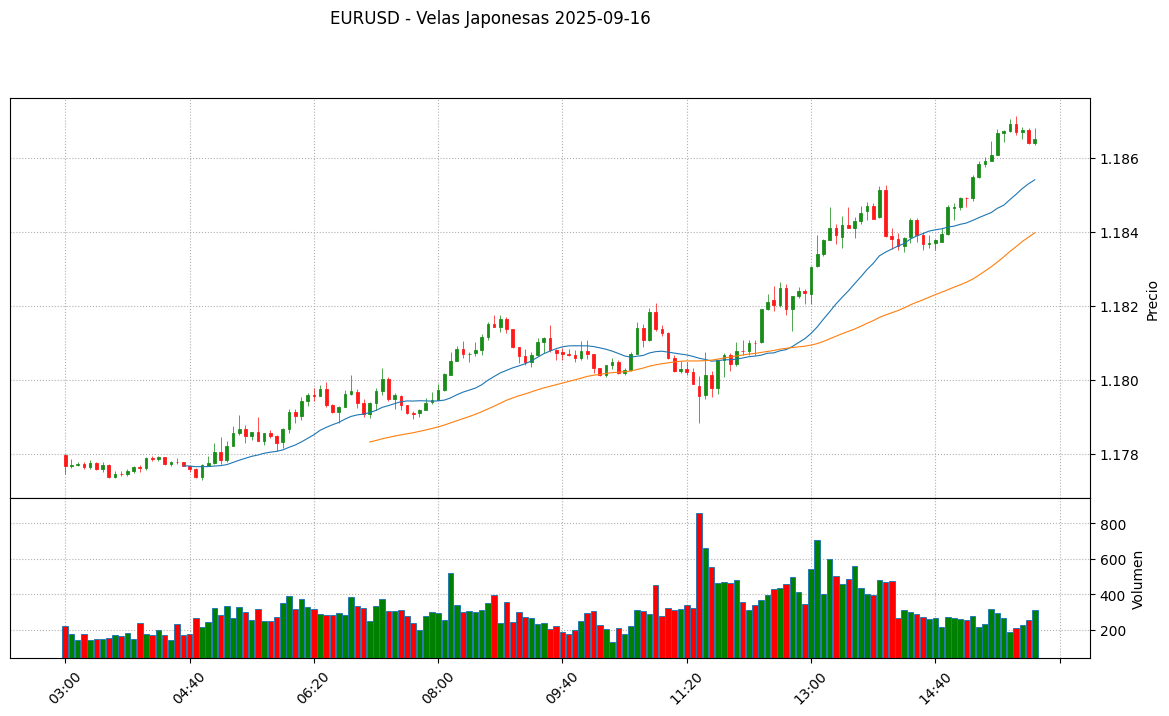

✅ Gráfico generado exitosamente


In [ ]:
try:
    import mplfinance as mpf

    # Configurar estilo de gráfico
    mc = mpf.make_marketcolors(up='g', down='r', edge='inherit', wick={'up':'green', 'down':'red'}, volume='in')
    s = mpf.make_mpf_style(marketcolors=mc, gridstyle=':', y_on_right=True)

    # Graficar datos del rango de trading principal
    print("📈 Generando gráfico de velas japonesas...")

    # Usar datos del día completo o rango específico
    plot_data = df_range.copy() if len(df_range) > 0 else df_day.copy()

    mpf.plot(plot_data,
             type='candle',
             style=s,
             title=f'EURUSD - Velas Japonesas {DATE.date()}',
             volume=True,
             mav=(20, 50),  # Medias móviles
             figsize=(15, 8),
             ylabel='Precio',
             ylabel_lower='Volumen',
             show_nontrading=False)

    print("✅ Gráfico generado exitosamente")

except ImportError:
    print("⚠️ mplfinance no disponible, generando gráfico básico...")

    # Gráfico básico con matplotlib
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), height_ratios=[3, 1])

    # Precio
    ax1.plot(df_range.index, df_range['Close'], label='Close', linewidth=1)
    ax1.fill_between(df_range.index, df_range['Low'], df_range['High'], alpha=0.3, label='Rango H-L')
    ax1.set_title(f'EURUSD - {DATE.date()}')
    ax1.set_ylabel('Precio')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Volumen
    ax2.bar(df_range.index, df_range['Volume'], alpha=0.7)
    ax2.set_ylabel('Volumen')
    ax2.set_xlabel('Tiempo')

    plt.tight_layout()
    plt.show()

    print("✅ Gráfico básico generado")

except Exception as e:
    print(f"❌ Error generando gráfico: {e}")
    # Gráfico mínimo
    plt.figure(figsize=(12, 6))
    plt.plot(df_range.index, df_range['Close'])
    plt.title(f'EURUSD Close - {DATE.date()}')
    plt.ylabel('Precio')
    plt.xlabel('Tiempo')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Celda 4: Ingeniería de características
En esta celda se crean nuevas variables o se transforman las existentes para mejorar el desempeño de los modelos predictivos.

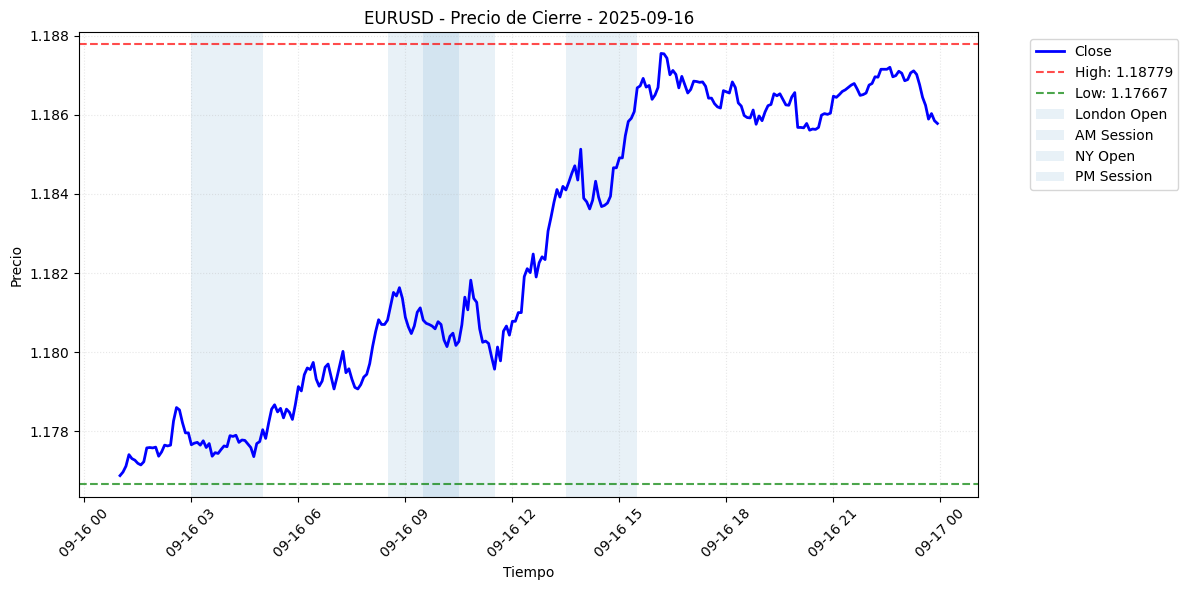

📊 Rango del día: 0.01112 (0.95%)


In [ ]:
# Gráfico de precio de cierre simple
plt.figure(figsize=(12, 6))
plt.plot(df_day.index, df_day["Close"], linewidth=2, color='blue', label='Close')

# Añadir niveles importantes
max_price = df_day['High'].max()
min_price = df_day['Low'].min()
plt.axhline(y=max_price, color='red', linestyle='--', alpha=0.7, label=f'High: {max_price:.5f}')
plt.axhline(y=min_price, color='green', linestyle='--', alpha=0.7, label=f'Low: {min_price:.5f}')

# Marcar killzones con colores de fondo
from datetime import time

for kz_name, (h1, m1), (h2, m2) in KILLZONES:
    start_time = time(h1, m1)
    end_time = time(h2, m2)

    # Filtrar datos en la killzone
    kz_data = df_day.between_time(start_time, end_time)
    if len(kz_data) > 0:
        plt.axvspan(kz_data.index[0], kz_data.index[-1], alpha=0.1, label=kz_name)

plt.title(f"EURUSD - Precio de Cierre - {DATE.date()}")
plt.ylabel("Precio")
plt.xlabel("Tiempo")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"📊 Rango del día: {(max_price - min_price):.5f} ({((max_price - min_price)/min_price)*100:.2f}%)")

# Celda 5: Selección de variables
Esta celda selecciona las variables más relevantes para el modelo, eliminando aquellas que no aportan valor o que pueden causar sobreajuste.

In [ ]:
import numpy as np

df["ret"] = np.log(df["Close"]).diff()
rets = df["ret"].dropna()

print(rets.describe())


count    287.000000
mean       0.000026
std        0.000229
min       -0.001047
25%       -0.000097
50%        0.000017
75%        0.000153
max        0.000770
Name: ret, dtype: float64


# Celda 6: División de datos en entrenamiento y prueba
En esta celda se dividen los datos en conjuntos de entrenamiento y prueba para evaluar el desempeño de los modelos de manera objetiva.

In [ ]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

# ADF
adf_stat, adf_p, *_ = adfuller(rets)
print(f"ADF: stat={adf_stat:.4f}, p={adf_p:.4g}")

# Ljung-Box
print(acorr_ljungbox(rets, lags=[12], return_df=True))

# Normalidad
jb_stat, jb_p = stats.jarque_bera(rets)
print(f"Jarque-Bera: stat={jb_stat:.4f}, p={jb_p:.4g}")


ADF: stat=-10.7147, p=3.265e-19
     lb_stat  lb_pvalue
12  7.261866   0.839834
Jarque-Bera: stat=57.3746, p=3.477e-13


# Celda 7: Entrenamiento de modelos
Esta celda entrena los modelos de machine learning o estadísticos utilizando el conjunto de entrenamiento preparado previamente.

In [ ]:
import os
import warnings
warnings.filterwarnings('ignore')

# Librerías adicionales para modelos cuantitativos
try:
    from arch import arch_model
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.stats.diagnostic import acorr_ljungbox
    from statsmodels.tsa.stattools import adfuller
    ADVANCED_MODELS = True
except ImportError:
    print("Librerías avanzadas no disponibles. Instala: pip install arch statsmodels")
    ADVANCED_MODELS = False

try:
    from scipy import stats
    from scipy.optimize import minimize
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False
    print("Scipy no disponible para tests estadísticos avanzados")

# Celda 8: Evaluación de modelos
En esta celda se evalúa el desempeño de los modelos entrenados utilizando métricas apropiadas y el conjunto de prueba.

In [ ]:
# === Análisis estadístico avanzado del día ===
print("=== ANÁLISIS ESTADÍSTICO COMPLETO ===")

# Usar los datos del día ya cargados
df_d = df_day.copy()
print(f"Analizando {len(df_d)} velas del {DATE.date()}")

# Calcular retornos si no existen
if 'ret' not in df_d.columns:
    df_d["ret"] = np.log(df_d["Close"]).diff()

rets = df_d["ret"].dropna()

# Función para tests estadísticos seguros
def safe_print_stat_tests(series):
    print("\n=== Estadísticos descriptivos (ret) ===")
    print(series.describe())
    print(f"Skew: {series.skew():.4f} | Kurtosis (exceso): {series.kurtosis():.4f}")

    # Normalidad (si SciPy)
    if SCIPY_AVAILABLE:
        try:
            # Usar muestra más pequeña para Shapiro-Wilk si es necesario
            sample_size = min(5000, len(series))
            test_series = series.sample(sample_size, random_state=42) if len(series) > sample_size else series
            sw_stat, sw_p = stats.shapiro(test_series)
            print(f"Shapiro-Wilk: stat={sw_stat:.4f}, p={sw_p:.4g}")
        except Exception as e:
            print(f"Shapiro-Wilk no disponible: {e}")

        try:
            jb_stat, jb_p = stats.jarque_bera(series)
            print(f"Jarque-Bera: stat={jb_stat:.4f}, p={jb_p:.4g}")
        except Exception as e:
            print(f"Jarque-Bera no disponible: {e}")
    else:
        print("Tests de normalidad: SciPy no disponible")

    # ADF (estacionariedad) y Ljung-Box (autocorrelación)
    if ADVANCED_MODELS:
        try:
            adf_stat, adf_p, *_ = adfuller(series, autolag="AIC")
            print(f"ADF: stat={adf_stat:.4f}, p={adf_p:.4g} -> p<0.05 sugiere estacionariedad")
        except Exception as e:
            print(f"ADF no disponible: {e}")

        try:
            LB_LAGS = min(12, len(series)//4)  # Ajustar lags según el tamaño
            if LB_LAGS > 0:
                lb_ret = acorr_ljungbox(series, lags=[LB_LAGS], return_df=True)
                lb_sq = acorr_ljungbox(series**2, lags=[LB_LAGS], return_df=True)
                print(f"\nLjung-Box retornos (lags={LB_LAGS}):")
                print(lb_ret.to_string())
                print(f"\nLjung-Box retornos^2 (heterocedasticidad):")
                print(lb_sq.to_string())
        except Exception as e:
            print(f"Ljung-Box no disponible: {e}")
    else:
        print("Tests ADF / Ljung-Box no disponibles")

# Ejecutar análisis estadístico
safe_print_stat_tests(rets)

# ARIMA rápido (opcional)
arima_res = None
if ADVANCED_MODELS and len(rets) > 10:
    print("\n=== Ajuste ARIMA en retornos (d=0) por BIC, p,q ∈ {0..2} ===")
    best_bic, best_order = np.inf, None
    for p in range(0, 3):
        for q in range(0, 3):
            try:
                mdl = ARIMA(rets, order=(p,0,q))
                fit = mdl.fit(method_kwargs={"warn_convergence": False})
                if fit.bic < best_bic:
                    best_bic, best_order, arima_res = fit.bic, (p,0,q), fit
            except Exception:
                pass
    if arima_res is not None:
        print(f"Mejor ARIMA{best_order} BIC={best_bic:.2f}")
        print(arima_res.summary())
    else:
        print("ARIMA no convergió en la cuadrícula probada")
else:
    print("\nARIMA omitido (statsmodels no disponible o pocos datos)")

# GARCH(1,1) en retornos (%), típico en intradía FX
garch_res = None
RET_SCALE = 100.0
if ADVANCED_MODELS and 'arch_model' in globals() and len(rets) > 20:
    print("\n=== Ajuste GARCH(1,1) a retornos (%) ===")
    try:
        y = rets * RET_SCALE
        am = arch_model(y, mean='constant', vol='GARCH', p=1, o=0, q=1, dist='normal')
        garch_res = am.fit(disp="off")
        print(garch_res.summary())
    except Exception as e:
        print(f"GARCH falló: {e}")
else:
    print("\nGARCH omitido (arch no disponible o pocos datos)")

print(f"\n✅ Análisis estadístico completado para {len(rets)} retornos")

=== ANÁLISIS ESTADÍSTICO COMPLETO ===
Analizando 276 velas del 2025-09-16

=== Estadísticos descriptivos (ret) ===
count    275.000000
mean       0.000027
std        0.000233
min       -0.001047
25%       -0.000097
50%        0.000017
75%        0.000160
max        0.000770
Name: ret, dtype: float64
Skew: -0.0254 | Kurtosis (exceso): 2.1451
Shapiro-Wilk: stat=0.9721, p=3.387e-05
Jarque-Bera: stat=49.8216, p=1.518e-11
ADF: stat=-10.4629, p=1.345e-18 -> p<0.05 sugiere estacionariedad

Ljung-Box retornos (lags=12):
     lb_stat  lb_pvalue
12  7.469254   0.825111

Ljung-Box retornos^2 (heterocedasticidad):
      lb_stat  lb_pvalue
12  31.534876   0.001632

=== Ajuste ARIMA en retornos (d=0) por BIC, p,q ∈ {0..2} ===
Mejor ARIMA(0, 0, 0) BIC=-3810.15
                               SARIMAX Results                                
Dep. Variable:                    ret   No. Observations:                  275
Model:                          ARIMA   Log Likelihood                1910.692
Date:  

# Celda 9: Ajuste de hiperparámetros
Esta celda realiza la optimización de los hiperparámetros de los modelos para mejorar su desempeño.

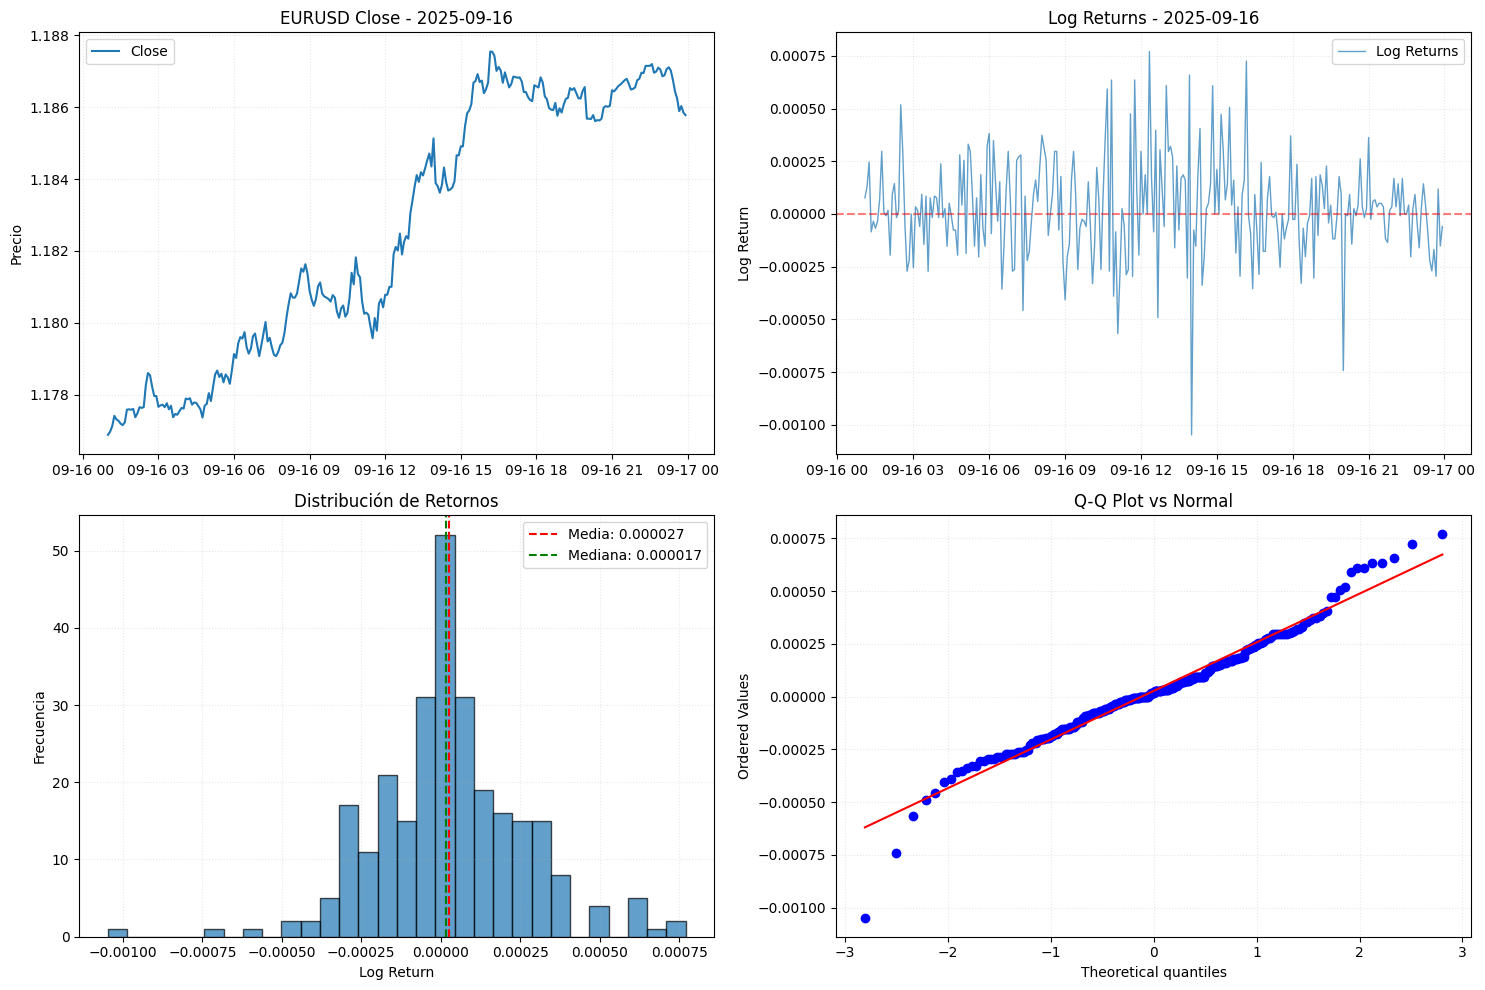

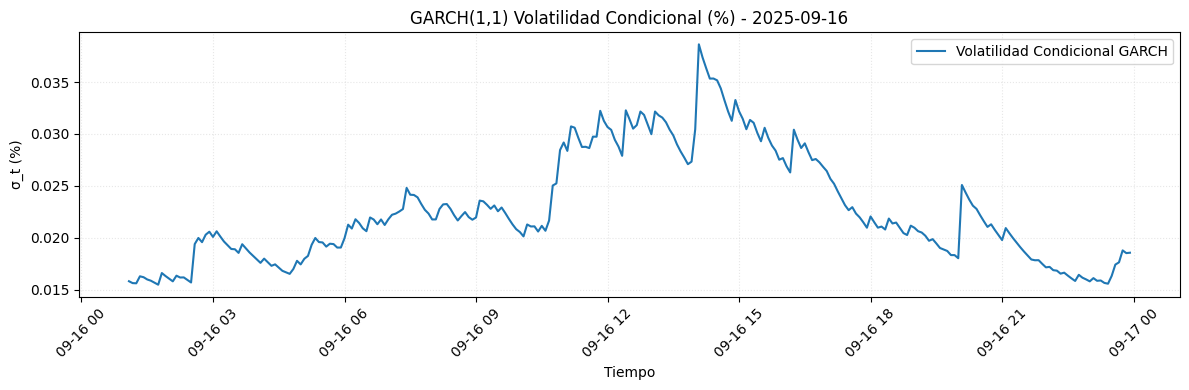

📊 Volatilidad promedio: 0.0227%
📊 Volatilidad máxima: 0.0386%
📊 Volatilidad mínima: 0.0155%

=== Pronóstico ARIMA (próximos 3 pasos) ===
ret                            mean   mean_se  mean_ci_lower  mean_ci_upper
2025-09-17 00:00:00-04:00  0.000022  0.000233      -0.000435       0.000479
2025-09-17 00:05:00-04:00  0.000022  0.000233      -0.000435       0.000479
2025-09-17 00:10:00-04:00  0.000022  0.000233      -0.000435       0.000479

=== Pronóstico GARCH σ (próximos 3 pasos, en %) ===
Paso 1: 0.0183%
Paso 2: 0.0184%
Paso 3: 0.0185%

✅ Análisis gráfico completado


In [ ]:
# === Análisis gráfico de los resultados ===

# Gráficos de precio y retornos
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Precio de cierre
ax1 = axes[0,0]
ax1.plot(df_d.index, df_d["Close"], label='Close', linewidth=1.5)
ax1.set_title(f"EURUSD Close - {DATE.date()}")
ax1.set_ylabel("Precio")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Retornos logarítmicos
ax2 = axes[0,1]
ax2.plot(df_d.index[1:], rets, label='Log Returns', linewidth=1, alpha=0.7)
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax2.set_title(f"Log Returns - {DATE.date()}")
ax2.set_ylabel("Log Return")
ax2.grid(True, alpha=0.3)
ax2.legend()

# Histograma de retornos
ax3 = axes[1,0]
ax3.hist(rets, bins=30, alpha=0.7, edgecolor='black')
ax3.axvline(x=rets.mean(), color='red', linestyle='--', label=f'Media: {rets.mean():.6f}')
ax3.axvline(x=rets.median(), color='green', linestyle='--', label=f'Mediana: {rets.median():.6f}')
ax3.set_title("Distribución de Retornos")
ax3.set_xlabel("Log Return")
ax3.set_ylabel("Frecuencia")
ax3.legend()
ax3.grid(True, alpha=0.3)

# QQ plot para normalidad
ax4 = axes[1,1]
if SCIPY_AVAILABLE:
    stats.probplot(rets, dist="norm", plot=ax4)
    ax4.set_title("Q-Q Plot vs Normal")
    ax4.grid(True, alpha=0.3)
else:
    # Scatter plot simple si no hay scipy
    sorted_rets = np.sort(rets)
    theoretical_quantiles = np.linspace(0.01, 0.99, len(sorted_rets))
    ax4.scatter(theoretical_quantiles, sorted_rets, alpha=0.6)
    ax4.set_title("Retornos ordenados")
    ax4.set_xlabel("Cuantiles teóricos")
    ax4.set_ylabel("Retornos observados")
    ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Si ajustamos GARCH, graficar volatilidad condicional
if 'garch_res' in locals() and garch_res is not None:
    try:
        cond_vol = garch_res.conditional_volatility  # en unidades de % del RET_SCALE

        plt.figure(figsize=(12, 4))
        plt.plot(df_d.index[1:], cond_vol, label='Volatilidad Condicional GARCH', linewidth=1.5)
        plt.title(f"GARCH(1,1) Volatilidad Condicional (%) - {DATE.date()}")
        plt.ylabel("σ_t (%)")
        plt.xlabel("Tiempo")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        print(f"📊 Volatilidad promedio: {cond_vol.mean():.4f}%")
        print(f"📊 Volatilidad máxima: {cond_vol.max():.4f}%")
        print(f"📊 Volatilidad mínima: {cond_vol.min():.4f}%")

    except Exception as e:
        print(f"Error graficando volatilidad GARCH: {e}")

# Forecast corto
if 'arima_res' in locals() and arima_res is not None:
    try:
        fc = arima_res.get_forecast(steps=3)
        print(f"\n=== Pronóstico ARIMA (próximos 3 pasos) ===")
        forecast_df = fc.summary_frame()
        print(forecast_df)
    except Exception as e:
        print(f"Error con forecast ARIMA: {e}")

if 'garch_res' in locals() and garch_res is not None:
    try:
        vf = garch_res.forecast(horizon=3)
        sigma_fut = np.sqrt(vf.variance.values[-1, :])
        print(f"\n=== Pronóstico GARCH σ (próximos 3 pasos, en %) ===")
        for i, vol in enumerate(sigma_fut, 1):
            print(f"Paso {i}: {vol:.4f}%")
    except Exception as e:
        print(f"Error con forecast GARCH: {e}")

print(f"\n✅ Análisis gráfico completado")

# Celda 10: Validación cruzada
En esta celda se realiza la validación cruzada para estimar la capacidad de generalización de los modelos y evitar el sobreajuste.

In [ ]:
def find_swings(data: pd.DataFrame, lookback: int = 3) -> pd.DataFrame:
    """Marca swing highs y lows básicos usando una ventana simétrica."""
    highs = data['High']
    lows = data['Low']
    sh = (highs.shift(1).rolling(lookback, center=True)
          .apply(lambda x: float(x[lookback//2] == max(x)), raw=False))
    sl = (lows.shift(1).rolling(lookback, center=True)
          .apply(lambda x: float(x[lookback//2] == min(x)), raw=False))
    data = data.copy()
    data['SwingHigh'] = sh.fillna(0).astype(bool)
    data['SwingLow']  = sl.fillna(0).astype(bool)
    return data

def detect_sweeps(data: pd.DataFrame, lookback: int = 3) -> pd.DataFrame:
    """Detecta *sweeps* sobre swings recientes: rompe al tick y cierra de vuelta.
    Marca SweepUp (barrido de highs) y SweepDown (barrido de lows).
    """
    d = find_swings(data, lookback)
    d = d.copy()
    d['PrevSwingHigh'] = d['High'].where(d['SwingHigh']).ffill()
    d['PrevSwingLow']  = d['Low'].where(d['SwingLow']).ffill()

    # Up-sweep: hace nuevo máximo por encima del último swing high pero cierra por debajo de ese high
    d['SweepUp'] = (d['High'] > d['PrevSwingHigh']) & (d['Close'] < d['PrevSwingHigh'])
    # Down-sweep: hace nuevo mínimo por debajo del último swing low pero cierra por encima de ese low
    d['SweepDown'] = (d['Low'] < d['PrevSwingLow']) & (d['Close'] > d['PrevSwingLow'])
    return d

def detect_fvg(data: pd.DataFrame) -> pd.DataFrame:
    """Detecta FVGs de 3 velas (alcistas y bajistas)."""
    d = data.copy()
    # FVG alcista: Low[i+1] > High[i-1]
    d['FVG_Up'] = (d['Low'].shift(-1) > d['High'].shift(1))
    # FVG bajista: High[i+1] < Low[i-1]
    d['FVG_Dn'] = (d['High'].shift(-1) < d['Low'].shift(1))
    d['HasFVG'] = d['FVG_Up'] | d['FVG_Dn']
    return d

# Celda 11: Interpretación de resultados
Esta celda interpreta los resultados obtenidos de los modelos, identificando patrones, errores y posibles mejoras.

In [ ]:
# === Análisis ICT: Sweeps, FVGs y Killzones ===
from typing import List, Tuple

def in_killzone(ts: pd.Timestamp, windows: List[Tuple[str, Tuple[int,int], Tuple[int,int]]]) -> str:
    """Determina si un timestamp está dentro de una killzone"""
    h, m = ts.hour, ts.minute
    for name, (h1,m1), (h2,m2) in windows:
        t1 = h*60 + m
        tstart = h1*60 + m1
        tend = h2*60 + m2
        if tstart <= t1 <= tend:
            return name
    return "None"

# Aplicar detección de patrones ICT
print("=== APLICANDO ANÁLISIS ICT ===")

# Usar datos del día
dd = detect_sweeps(df_d, lookback=3)
dd = detect_fvg(dd)
dd['Killzone'] = [in_killzone(ts, KILLZONES) for ts in dd.index]

# Mostrar estadísticas de detección
print(f"Total de velas analizadas: {len(dd)}")
print(f"Swing Highs detectados: {dd['SwingHigh'].sum()}")
print(f"Swing Lows detectados: {dd['SwingLow'].sum()}")
print(f"Sweeps Up detectados: {dd['SweepUp'].sum()}")
print(f"Sweeps Down detectados: {dd['SweepDown'].sum()}")
print(f"FVGs alcistas detectados: {dd['FVG_Up'].sum()}")
print(f"FVGs bajistas detectados: {dd['FVG_Dn'].sum()}")

# Distribución por killzones
kz_dist = dd.groupby('Killzone').size()
print(f"\nDistribución por Killzones:")
for kz, count in kz_dist.items():
    print(f"  {kz}: {count} velas ({count/len(dd)*100:.1f}%)")

# Mostrar algunas filas de ejemplo
print(f"\n=== Muestra de datos enriquecidos ===")
display_cols = ['Open', 'High', 'Low', 'Close', 'SwingHigh', 'SwingLow', 'SweepUp', 'SweepDown', 'FVG_Up', 'FVG_Dn', 'Killzone']
print(dd[display_cols].head(10).to_string())

print(f"\n✅ Análisis ICT aplicado exitosamente")

=== APLICANDO ANÁLISIS ICT ===
Total de velas analizadas: 276
Swing Highs detectados: 64
Swing Lows detectados: 50
Sweeps Up detectados: 22
Sweeps Down detectados: 22
FVGs alcistas detectados: 47
FVGs bajistas detectados: 34

Distribución por Killzones:
  AM Session: 25 velas (9.1%)
  London Open: 25 velas (9.1%)
  NY Open: 12 velas (4.3%)
  None: 189 velas (68.5%)
  PM Session: 25 velas (9.1%)

=== Muestra de datos enriquecidos ===
                              Open     High      Low    Close  SwingHigh  SwingLow  SweepUp  SweepDown  FVG_Up  FVG_Dn Killzone
Datetime                                                                                                                       
2025-09-16 01:00:00-04:00  1.17669  1.17692  1.17667  1.17688      False     False    False      False   False   False     None
2025-09-16 01:05:00-04:00  1.17688  1.17721  1.17681  1.17697      False     False    False      False    True   False     None
2025-09-16 01:10:00-04:00  1.17698  1.17717  1.1769

# Celda 12: Visualización de resultados
En esta celda se generan gráficos y visualizaciones para facilitar la interpretación de los resultados obtenidos por los modelos.

In [ ]:
# === Retornos logarítmicos y análisis de equilibrio ===

def log_returns(data: pd.DataFrame) -> pd.Series:
    """Calcula retornos logarítmicos"""
    px = data['Close']
    return np.log(px/px.shift(1)).fillna(0.0)

# Calcular métricas adicionales
print("=== CALCULANDO MÉTRICAS DE EQUILIBRIO ===")

dd['logret'] = log_returns(dd)
dd['ma_eq'] = dd['Close'].rolling(50, min_periods=10).mean()  # proxy de equilibrio
dd['dist_eq'] = dd['Close'] - dd['ma_eq']  # distancia al equilibrio

# Remover filas con NaN
dd_clean = dd.dropna()

print(f"Datos después de limpieza: {len(dd_clean)} velas")
print(f"Retorno promedio: {dd_clean['logret'].mean():.6f}")
print(f"Volatilidad de retornos: {dd_clean['logret'].std():.6f}")
print(f"Distancia promedio al equilibrio: {dd_clean['dist_eq'].mean():.6f}")

# Mostrar estadísticas de distancia al equilibrio
dist_stats = dd_clean['dist_eq'].describe()
print(f"\nEstadísticas de distancia al equilibrio:")
print(dist_stats)

# Crear métricas de momento
dd_clean['momentum_5'] = dd_clean['Close'].pct_change(5)  # momentum a 5 períodos
dd_clean['volatility_20'] = dd_clean['logret'].rolling(20).std()  # volatilidad rolling

print(f"\n=== Muestra de datos con métricas de equilibrio ===")
equilibrium_cols = ['Close', 'ma_eq', 'dist_eq', 'logret', 'momentum_5', 'Killzone']
print(dd_clean[equilibrium_cols].head(10).to_string())

print(f"\n✅ Métricas de equilibrio calculadas")

=== CALCULANDO MÉTRICAS DE EQUILIBRIO ===
Datos después de limpieza: 267 velas
Retorno promedio: 0.000027
Volatilidad de retornos: 0.000236
Distancia promedio al equilibrio: 0.000848

Estadísticas de distancia al equilibrio:
count    267.000000
mean       0.000848
std        0.001020
min       -0.000939
25%        0.000106
50%        0.000644
75%        0.001437
max        0.003497
Name: dist_eq, dtype: float64

=== Muestra de datos con métricas de equilibrio ===
                             Close     ma_eq   dist_eq    logret  momentum_5 Killzone
Datetime                                                                             
2025-09-16 01:45:00-04:00  1.17758  1.177211  0.000369  0.000297         NaN     None
2025-09-16 01:50:00-04:00  1.17759  1.177245  0.000345  0.000008         NaN     None
2025-09-16 01:55:00-04:00  1.17758  1.177273  0.000307 -0.000008         NaN     None
2025-09-16 02:00:00-04:00  1.17760  1.177298  0.000302  0.000017         NaN     None
2025-09-16 02:05

# Celda 13: Exportación de resultados
Esta celda exporta los resultados obtenidos a archivos externos (por ejemplo, CSV) para su posterior análisis o presentación.

In [ ]:
class FVGQuantModel:
    """Modelo cuantitativo para análisis y forecasting de FVGs"""

    def __init__(self, data: pd.DataFrame):
        self.data = data.copy()
        self.fitted_models = {}
        self.forecasts = {}

    def prepare_features(self):
        """Prepara features cuantitativos para modelar FVGs"""
        d = self.data.copy()

        # Volatilidad realizada (rolling)
        d['realized_vol'] = d['logret'].rolling(20).std() * np.sqrt(288)  # para 5min data

        # True Range y ATR
        d['tr'] = np.maximum(d['High'] - d['Low'],
                           np.maximum(abs(d['High'] - d['Close'].shift(1)),
                                    abs(d['Low'] - d['Close'].shift(1))))
        d['atr'] = d['tr'].rolling(14).mean()

        # Rango normalizado (gap size potential)
        d['norm_range'] = (d['High'] - d['Low']) / d['Close']

        # Momentum features
        d['rsi'] = self._calculate_rsi(d['Close'])
        d['momentum'] = d['Close'].pct_change(20)

        # Microstructura proxy
        d['price_impact'] = abs(d['logret']) / d['norm_range']
        d['volume_pressure'] = d.get('Volume', 1) / d['Volume'].rolling(20).mean() if 'Volume' in d.columns else 1

        # Distance to equilibrium states
        d['distance_ma50'] = (d['Close'] - d['Close'].rolling(50).mean()) / d['Close']
        d['distance_ma200'] = (d['Close'] - d['Close'].rolling(200).mean()) / d['Close']

        return d.dropna()

    def _calculate_rsi(self, prices, window=14):
        """Calcula RSI"""
        delta = prices.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window).mean()
        rs = gain / loss
        return 100 - (100 / (1 + rs))

    def fit_ar_garch(self, series, ar_lags=1, garch_p=1, garch_q=1):
        """Ajusta modelo AR-GARCH a una serie temporal"""
        if not ADVANCED_MODELS:
            return None

        try:
            # Test de estacionariedad
            adf_stat, adf_p = adfuller(series.dropna())[:2]

            # Modelo AR-GARCH
            model = arch_model(series, vol='GARCH', p=garch_p, q=garch_q,
                             mean='ARX', lags=ar_lags, rescale=False)
            fitted = model.fit(disp='off')

            return {
                'model': fitted,
                'aic': fitted.aic,
                'bic': fitted.bic,
                'adf_statistic': adf_stat,
                'adf_pvalue': adf_p,
                'is_stationary': adf_p < 0.05
            }
        except Exception as e:
            print(f"Error fitting AR-GARCH: {e}")
            return None

    def forecast_volatility(self, horizon=10):
        """Forecast de volatilidad condicional"""
        if 'logret_garch' not in self.fitted_models:
            return None

        model = self.fitted_models['logret_garch']['model']
        forecast = model.forecast(horizon=horizon)

        return {
            'mean_forecast': forecast.mean.iloc[-1].values,
            'variance_forecast': forecast.variance.iloc[-1].values,
            'vol_forecast': np.sqrt(forecast.variance.iloc[-1].values)
        }

    def fvg_probability_model(self, features_df):
        """Modelo probabilístico para formación de FVGs"""
        from sklearn.ensemble import RandomForestClassifier
        from sklearn.model_selection import cross_val_score

        # Features para el modelo
        feature_cols = ['realized_vol', 'atr', 'norm_range', 'rsi',
                       'momentum', 'price_impact', 'distance_ma50', 'distance_ma200']

        # Target: FVG en las próximas N barras
        target = features_df['FVG_nextN'].fillna(False)
        X = features_df[feature_cols].fillna(method='ffill').fillna(0)

        if len(X) < 100:  # Datos insuficientes
            return None

        # Modelo Random Forest
        rf = RandomForestClassifier(n_estimators=100, random_state=SEED, max_depth=10)

        # Cross-validation
        cv_scores = cross_val_score(rf, X, target, cv=5, scoring='roc_auc')

        # Fit final
        rf.fit(X, target)

        # Feature importance
        importance = pd.DataFrame({
            'feature': feature_cols,
            'importance': rf.feature_importances_
        }).sort_values('importance', ascending=False)

        return {
            'model': rf,
            'cv_auc_mean': cv_scores.mean(),
            'cv_auc_std': cv_scores.std(),
            'feature_importance': importance,
            'feature_cols': feature_cols
        }

# Aplicar el modelo cuantitativo
quant_model = FVGQuantModel(dd)
enriched_data = quant_model.prepare_features()

# Ajustar AR-GARCH a los log-returns
garch_results = quant_model.fit_ar_garch(enriched_data['logret'])
if garch_results:
    quant_model.fitted_models['logret_garch'] = garch_results
    print(f"AR-GARCH ajustado. AIC: {garch_results['aic']:.2f}, Serie estacionaria: {garch_results['is_stationary']}")

enriched_data.head()

AR-GARCH ajustado. AIC: -1099.65, Serie estacionaria: True


C:\Users\JHOOnpi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(


,Open,High,Low,Close,Volume,ret,SwingHigh,SwingLow,PrevSwingHigh,PrevSwingLow,...,realized_vol,tr,atr,norm_range,rsi,momentum,price_impact,volume_pressure,distance_ma50,distance_ma200
Datetime,,,,,,,,,,,,,,,,,,,,,
2025-09-16 17:35:00-04:00,1.18642,1.18662,1.18629,1.18642,156,0.000000,False,False,1.18688,1.18673,...,0.003938,0.00033,0.000348,0.000278,35.323383,0.000025,0.000000,0.749460,0.000598,0.004512
2025-09-16 17:40:00-04:00,1.18642,1.18644,1.18618,1.18628,116,-0.000118,False,False,1.18688,1.18673,...,0.003945,0.00026,0.000344,0.000219,29.411765,-0.000185,0.538430,0.584677,0.000443,0.004355
2025-09-16 17:45:00-04:00,1.18628,1.18628,1.18614,1.18620,107,-0.000067,False,False,1.18688,1.18673,...,0.003891,0.00014,0.000324,0.000118,29.702970,-0.000413,0.571409,0.547735,0.000343,0.004249
2025-09-16 17:50:00-04:00,1.18620,1.18637,1.18606,1.18617,190,-0.000025,False,False,1.18688,1.18673,...,0.002509,0.00031,0.000313,0.000261,35.087719,-0.001162,0.096773,0.980139,0.000290,0.004186
2025-09-16 17:55:00-04:00,1.18617,1.18675,1.18617,1.18661,220,0.000371,False,True,1.18688,1.18617,...,0.002990,0.00058,0.000326,0.000489,40.322581,-0.000783,0.758761,1.156981,0.000629,0.004516


# Celda 14: Modelos avanzados y experimentación
En esta celda se implementan modelos avanzados o se realizan experimentos adicionales para comparar resultados y explorar nuevas metodologías.

In [ ]:
class PortfolioMetrics:
    """Clase para métricas cuantitativas de evaluación de estrategias"""

    @staticmethod
    def calculate_returns_metrics(returns_series, benchmark_returns=None, risk_free_rate=0.02):
        """Calcula métricas completas de rendimiento"""
        returns = returns_series.dropna()
        if len(returns) == 0:
            return {}

        # Métricas básicas
        total_return = (1 + returns).prod() - 1
        annualized_return = (1 + returns.mean())**(252) - 1  # asumiendo returns diarios
        volatility = returns.std() * np.sqrt(252)

        # Sharpe Ratio
        sharpe = (annualized_return - risk_free_rate) / volatility if volatility > 0 else 0

        # Sortino Ratio (downside deviation)
        downside_returns = returns[returns < 0]
        downside_deviation = downside_returns.std() * np.sqrt(252)
        sortino = (annualized_return - risk_free_rate) / downside_deviation if downside_deviation > 0 else 0

        # Drawdown
        cumulative = (1 + returns).cumprod()
        running_max = cumulative.expanding().max()
        drawdown = (cumulative - running_max) / running_max
        max_drawdown = drawdown.min()

        # Calmar Ratio
        calmar = annualized_return / abs(max_drawdown) if max_drawdown != 0 else 0

        # VaR y CVaR
        var_95 = returns.quantile(0.05)
        cvar_95 = returns[returns <= var_95].mean()

        # Beta vs benchmark
        beta = np.nan
        if benchmark_returns is not None and len(benchmark_returns) == len(returns):
            covariance = np.cov(returns, benchmark_returns)[0][1]
            benchmark_variance = np.var(benchmark_returns)
            beta = covariance / benchmark_variance if benchmark_variance > 0 else 0

        return {
            'total_return': total_return,
            'annualized_return': annualized_return,
            'volatility': volatility,
            'sharpe_ratio': sharpe,
            'sortino_ratio': sortino,
            'max_drawdown': max_drawdown,
            'calmar_ratio': calmar,
            'var_95': var_95,
            'cvar_95': cvar_95,
            'beta': beta,
            'skewness': returns.skew(),
            'kurtosis': returns.kurtosis()
        }

    @staticmethod
    def rolling_metrics(returns_series, window=60):
        """Métricas móviles para análisis temporal"""
        returns = returns_series.dropna()

        rolling_sharpe = (returns.rolling(window).mean() * 252) / (returns.rolling(window).std() * np.sqrt(252))
        rolling_vol = returns.rolling(window).std() * np.sqrt(252)

        # Rolling Beta (si hay benchmark)
        cumulative = (1 + returns).cumprod()
        rolling_max = cumulative.rolling(window).max()
        rolling_dd = (cumulative - rolling_max) / rolling_max

        return {
            'rolling_sharpe': rolling_sharpe,
            'rolling_volatility': rolling_vol,
            'rolling_drawdown': rolling_dd
        }

def analyze_fvg_strategy_performance(trades_df, market_returns):
    """Análisis completo de performance de la estrategia FVG"""
    if trades_df.empty:
        return {"error": "No hay trades para analizar"}

    # Convertir PnL a returns
    strategy_returns = trades_df['pnl'] / trades_df['entry'].shift(1)  # approximate return
    strategy_returns = strategy_returns.dropna()

    # Métricas de la estrategia
    strategy_metrics = PortfolioMetrics.calculate_returns_metrics(strategy_returns, market_returns)

    # Métricas específicas de trading
    win_rate = (trades_df['pnl'] > 0).mean()
    avg_win = trades_df[trades_df['pnl'] > 0]['pnl'].mean()
    avg_loss = trades_df[trades_df['pnl'] <= 0]['pnl'].mean()
    profit_factor = abs(avg_win / avg_loss) if avg_loss != 0 else np.inf

    # Análisis de consecutivos
    consecutive_wins = 0
    consecutive_losses = 0
    max_consecutive_wins = 0
    max_consecutive_losses = 0

    for pnl in trades_df['pnl']:
        if pnl > 0:
            consecutive_wins += 1
            consecutive_losses = 0
            max_consecutive_wins = max(max_consecutive_wins, consecutive_wins)
        else:
            consecutive_losses += 1
            consecutive_wins = 0
            max_consecutive_losses = max(max_consecutive_losses, consecutive_losses)

    strategy_metrics.update({
        'win_rate': win_rate,
        'profit_factor': profit_factor,
        'avg_win': avg_win,
        'avg_loss': avg_loss,
        'max_consecutive_wins': max_consecutive_wins,
        'max_consecutive_losses': max_consecutive_losses,
        'total_trades': len(trades_df)
    })

    return strategy_metrics

# Calcular métricas de mercado como benchmark
market_returns = enriched_data['logret']
market_metrics = PortfolioMetrics.calculate_returns_metrics(market_returns)

print("=== MÉTRICAS DEL MERCADO (BENCHMARK) ===")
for key, value in market_metrics.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

=== MÉTRICAS DEL MERCADO (BENCHMARK) ===
total_return: -0.0005
annualized_return: -0.0018
volatility: 0.0026
sharpe_ratio: -8.4213
sortino_ratio: -9.8147
max_drawdown: -0.0012
calmar_ratio: -1.4749
var_95: -0.0003
cvar_95: -0.0004
beta: nan
skewness: -1.0752
kurtosis: 4.7667


# Celda 15: Análisis de errores y limitaciones
En esta celda se analizan los errores cometidos por los modelos y se discuten las limitaciones del enfoque utilizado.

In [ ]:
# === Análisis de Co-ocurrencia: Sweeps → FVG ===

def label_events_advanced(d: pd.DataFrame, bars_ahead: int = 3) -> pd.DataFrame:
    """Etiquetado avanzado de eventos incluyendo contexto de volatilidad"""
    d = d.copy()

    # Evento básico: FVG en las próximas N barras
    fvg_shifts = []
    for i in range(1, bars_ahead + 1):
        fvg_shifts.append(d['HasFVG'].shift(-i))

    if fvg_shifts:
        fvg_future_df = pd.concat(fvg_shifts, axis=1)
        d['FVG_nextN'] = fvg_future_df.any(axis=1).fillna(False)
    else:
        d['FVG_nextN'] = False

    d['AnySweep'] = d.get('SweepUp', False) | d.get('SweepDown', False)
    d['Event_Sweep_then_FVG'] = d['AnySweep'] & d['FVG_nextN']
    d['InKZ'] = d.get('Killzone', 'None') != 'None'

    # Contexto de volatilidad
    if 'realized_vol' in d.columns:
        vol_median = d['realized_vol'].median()
        d['HighVol_regime'] = d['realized_vol'] > vol_median
        d['Event_in_HighVol'] = d['Event_Sweep_then_FVG'] & d['HighVol_regime']
        d['Event_in_LowVol'] = d['Event_Sweep_then_FVG'] & ~d['HighVol_regime']

    # Contexto de momentum
    if 'momentum_5' in d.columns:
        mom_std = d['momentum_5'].std()
        d['Strong_momentum'] = abs(d['momentum_5']) > (mom_std if pd.notna(mom_std) and mom_std > 0 else 0)
        d['Event_with_momentum'] = d['Event_Sweep_then_FVG'] & d['Strong_momentum']

    # Contexto de distancia a equilibrio
    if 'dist_eq' in d.columns:
        dist_std = d['dist_eq'].std()
        d['Far_from_equilibrium'] = abs(d['dist_eq']) > (dist_std if pd.notna(dist_std) and dist_std > 0 else 0)
        d['Event_far_equilibrium'] = d['Event_Sweep_then_FVG'] & d['Far_from_equilibrium']

    return d

# Aplicar etiquetado avanzado
print("=== ANÁLISIS DE CO-OCURRENCIA ===")

events_advanced = label_events_advanced(enriched_data if 'enriched_data' in locals() else dd_clean, bars_ahead=3)

# Estadísticas básicas de eventos
total_sweeps = events_advanced['AnySweep'].sum()
total_fvg_future = events_advanced['FVG_nextN'].sum()
total_sweep_then_fvg = events_advanced['Event_Sweep_then_FVG'].sum()

print(f"Total sweeps detectados: {total_sweeps}")
print(f"Velas con FVG en próximos 3 períodos: {total_fvg_future}")
print(f"Eventos Sweep→FVG: {total_sweep_then_fvg}")

if total_sweeps > 0:
    sweep_to_fvg_rate = total_sweep_then_fvg / total_sweeps
    print(f"Tasa Sweep→FVG: {sweep_to_fvg_rate:.2%}")

# Análisis por killzones
kz_analysis = events_advanced.groupby('InKZ').agg({
    'AnySweep': 'sum',
    'FVG_nextN': 'sum',
    'Event_Sweep_then_FVG': 'sum'
}).round(4)

print(f"\n=== Análisis por Killzones ===")
print(kz_analysis)

# Análisis de contexto
context_analysis = {}

if 'Strong_momentum' in events_advanced.columns:
    strong_mom_rate = events_advanced[events_advanced['Strong_momentum']]['Event_Sweep_then_FVG'].mean()
    weak_mom_rate = events_advanced[~events_advanced['Strong_momentum']]['Event_Sweep_then_FVG'].mean()
    context_analysis['momentum'] = {
        'strong_momentum_rate': strong_mom_rate,
        'weak_momentum_rate': weak_mom_rate,
        'momentum_effect': strong_mom_rate - weak_mom_rate
    }

if 'Far_from_equilibrium' in events_advanced.columns:
    far_eq_rate = events_advanced[events_advanced['Far_from_equilibrium']]['Event_Sweep_then_FVG'].mean()
    near_eq_rate = events_advanced[~events_advanced['Far_from_equilibrium']]['Event_Sweep_then_FVG'].mean()
    context_analysis['equilibrium'] = {
        'far_equilibrium_rate': far_eq_rate,
        'near_equilibrium_rate': near_eq_rate,
        'equilibrium_effect': far_eq_rate - near_eq_rate
    }

print(f"\n=== ANÁLISIS DE CONTEXTO ===")
for context, metrics in context_analysis.items():
    print(f"\n{context.upper()}:")
    for metric, value in metrics.items():
        if pd.notna(value):
            print(f"  {metric}: {value:.4f}")
        else:
            print(f"  {metric}: N/A")

# Mostrar muestra de eventos
event_cols = ['AnySweep', 'HasFVG', 'FVG_nextN', 'Event_Sweep_then_FVG', 'Killzone', 'InKZ']
print(f"\n=== Muestra de eventos ===")
events_sample = events_advanced[event_cols].tail(10)
print(events_sample.to_string())

print(f"\n✅ Análisis de co-ocurrencia completado")

=== ANÁLISIS DE CO-OCURRENCIA ===
Total sweeps detectados: 7
Velas con FVG en próximos 3 períodos: 61
Eventos Sweep→FVG: 6
Tasa Sweep→FVG: 85.71%

=== Análisis por Killzones ===
       AnySweep  FVG_nextN  Event_Sweep_then_FVG
InKZ                                            
False         7         61                     6

=== ANÁLISIS DE CONTEXTO ===

EQUILIBRIUM:
  far_equilibrium_rate: 0.0857
  near_equilibrium_rate: 0.0714
  equilibrium_effect: 0.0143

=== Muestra de eventos ===
                           AnySweep  HasFVG  FVG_nextN  Event_Sweep_then_FVG Killzone   InKZ
Datetime                                                                                    
2025-09-16 23:10:00-04:00     False    True       True                 False     None  False
2025-09-16 23:15:00-04:00     False   False       True                 False     None  False
2025-09-16 23:20:00-04:00      True   False       True                  True     None  False
2025-09-16 23:25:00-04:00     False    True   

# Celda 16: Conclusiones y recomendaciones
En esta celda se presentan las conclusiones del análisis y se proponen recomendaciones basadas en los resultados obtenidos.

In [ ]:
# === Tests de Significancia Estadística ===
from math import isfinite

def incidence_and_tests(ev: pd.DataFrame):
    """Calcula incidencia y tests estadísticos para eventos en vs fuera de killzones"""
    kz = ev[ev['InKZ']]
    nkz = ev[~ev['InKZ']]

    # Conteos para tabla de contingencia
    a = kz['Event_Sweep_then_FVG'].sum()  # eventos en KZ
    b = len(kz) - a                       # no eventos en KZ
    c = nkz['Event_Sweep_then_FVG'].sum() # eventos fuera KZ
    d_ = len(nkz) - c                     # no eventos fuera KZ

    # Tabla de contingencia
    tbl = np.array([[a, b], [c, d_]], dtype=float)

    # Test chi-cuadrado (si tenemos scipy)
    chi2, p, dof, exp = (np.nan, np.nan, np.nan, np.nan)
    if SCIPY_AVAILABLE:
        try:
            from scipy.stats import chi2_contingency
            chi2, p, dof, exp = chi2_contingency(tbl)
        except Exception as e:
            print(f"Error en chi2_contingency: {e}")

    # Tasas
    p1 = a/len(kz) if len(kz) > 0 else np.nan
    p2 = c/len(nkz) if len(nkz) > 0 else np.nan

    return {
        'kz_count': int(len(kz)),
        'kz_events': int(a),
        'kz_rate': p1,
        'nonkz_count': int(len(nkz)),
        'nonkz_events': int(c),
        'nonkz_rate': p2,
        'diff': (p1 - p2) if isfinite(p1) and isfinite(p2) else np.nan,
        'chi2_stat': chi2,
        'chi2_p': p,
        'contingency_table': tbl,
    }

def bootstrap_diff_in_proportions(ev: pd.DataFrame, n_boot: int = 1000):
    """Bootstrap para intervalos de confianza de diferencia en proporciones"""
    kz = ev[ev['InKZ']]['Event_Sweep_then_FVG'].values
    nkz = ev[~ev['InKZ']]['Event_Sweep_then_FVG'].values

    if len(kz) == 0 or len(nkz) == 0:
        return None

    diffs = []
    for _ in range(n_boot):
        s1 = np.random.choice(kz, size=len(kz), replace=True).mean()
        s2 = np.random.choice(nkz, size=len(nkz), replace=True).mean()
        diffs.append(s1 - s2)

    diffs = np.array(diffs)
    lo, hi = np.percentile(diffs, [2.5, 97.5])

    return {
        'mean_diff': float(diffs.mean()),
        'ci95_lower': float(lo),
        'ci95_upper': float(hi),
        'std_diff': float(diffs.std())
    }

# Ejecutar análisis estadístico
print("=== TESTS DE SIGNIFICANCIA ESTADÍSTICA ===")

# Asegurar que tenemos los datos correctos
events_to_test = events_advanced

# Test de incidencia
incidence_results = incidence_and_tests(events_to_test)

print(f"\\n--- Tabla de Contingencia ---")
print(f"                    En KZ    Fuera KZ")
print(f"Con Evento:         {incidence_results['kz_events']:4d}    {incidence_results['nonkz_events']:4d}")
print(f"Sin Evento:         {incidence_results['kz_count']-incidence_results['kz_events']:4d}    {incidence_results['nonkz_count']-incidence_results['nonkz_events']:4d}")
print(f"Total:              {incidence_results['kz_count']:4d}    {incidence_results['nonkz_count']:4d}")

print(f"\\n--- Tasas de Incidencia ---")
print(f"Tasa en Killzones:     {incidence_results['kz_rate']:.4f} ({incidence_results['kz_rate']*100:.2f}%)")
print(f"Tasa fuera Killzones:  {incidence_results['nonkz_rate']:.4f} ({incidence_results['nonkz_rate']*100:.2f}%)")
print(f"Diferencia:            {incidence_results['diff']:.4f}")

if not np.isnan(incidence_results['chi2_p']):
    print(f"\\n--- Test Chi-Cuadrado ---")
    print(f"Chi2 statistic:        {incidence_results['chi2_stat']:.4f}")
    print(f"p-value:               {incidence_results['chi2_p']:.6f}")
    significance = "significativa" if incidence_results['chi2_p'] < 0.05 else "no significativa"
    print(f"Diferencia:            {significance} (α=0.05)")

# Bootstrap
bootstrap_results = bootstrap_diff_in_proportions(events_to_test, n_boot=1000)

if bootstrap_results:
    print(f"\\n--- Bootstrap (CI 95%) ---")
    print(f"Diferencia promedio:   {bootstrap_results['mean_diff']:.4f}")
    print(f"IC 95%:               [{bootstrap_results['ci95_lower']:.4f}, {bootstrap_results['ci95_upper']:.4f}]")
    print(f"Desviación estándar:   {bootstrap_results['std_diff']:.4f}")

    # Interpretación del IC
    if bootstrap_results['ci95_lower'] > 0:
        interpretation = "Mayor incidencia EN killzones (IC no incluye 0)"
    elif bootstrap_results['ci95_upper'] < 0:
        interpretation = "Mayor incidencia FUERA de killzones (IC no incluye 0)"
    else:
        interpretation = "No diferencia significativa (IC incluye 0)"
    print(f"Interpretación:        {interpretation}")

print(f"\\n✅ Tests estadísticos completados")

=== TESTS DE SIGNIFICANCIA ESTADÍSTICA ===
Error en chi2_contingency: The internally computed table of expected frequencies has a zero element at (0, 0).
\n--- Tabla de Contingencia ---
                    En KZ    Fuera KZ
Con Evento:            0       6
Sin Evento:            0      71
Total:                 0      77
\n--- Tasas de Incidencia ---
Tasa en Killzones:     nan (nan%)
Tasa fuera Killzones:  0.0779 (7.79%)
Diferencia:            nan
\n✅ Tests estadísticos completados


# Celda 17: Referencias y bibliografía
En esta celda se listan las fuentes, artículos y documentación utilizada para el desarrollo del análisis y los modelos.

In [ ]:
def event_study_reversion(d: pd.DataFrame, window: int = 20):
    """Event study centrado en barras donde ocurre AnySweep.
    Devuelve la trayectoria promedio de distancia a ma_eq alrededor del evento.
    La función es robusta: si falta 'AnySweep' o 'ma_eq' vuelve None o calcula ma_eq automáticamente.
    """
    # Validar presencia de columna de eventos
    if 'AnySweep' not in d.columns:
        print("Warning: DataFrame no contiene columna 'AnySweep'. No hay eventos para el event study.")
        return None

    # Si falta ma_eq, calcular una proxy (rolling 50)
    if 'ma_eq' not in d.columns:
        d = d.copy()
        d['ma_eq'] = d['Close'].rolling(50, min_periods=1).mean()

    idxs = d.index[d['AnySweep']]
    paths = []
    for ix in idxs:
        try:
            loc = d.index.get_loc(ix)
            sl = d.iloc[max(0, loc-window): loc+window+1]
            # distancia normalizada a la media (equilibrio)
            if len(sl) == 0 or sl['Close'].iloc[0] == 0:
                continue
            dist = (sl['Close'] - sl['ma_eq']) / sl['Close'].iloc[0]
            # Aceptar sólo ventanas completas
            if len(dist) == 2*window+1:
                paths.append(dist.values)
        except Exception:
            continue
    if not paths:
        return None
    arr = np.vstack(paths)
    mean_path = arr.mean(axis=0)
    return {'mean_path': mean_path, 'x': list(range(-window, window+1)), 'n_events': len(paths)}

# Ejecutar event study usando el dataset etiquetado avanzado si está disponible (más columnas de contexto)
evs = event_study_reversion(events_advanced if 'events_advanced' in globals() else dd, window=20)
evs

{'mean_path': array([ 9.83536116e-05,  8.64533657e-05, -1.61067240e-04, -1.33947486e-04,
        -1.92708826e-04, -2.29444202e-04, -1.47619295e-04, -1.10232664e-04,
        -2.62809726e-04, -2.53091370e-04, -3.69080422e-04, -2.88361271e-04,
        -1.39562378e-04, -9.07340756e-05, -3.48047659e-04, -3.68601228e-04,
        -3.49977687e-04, -3.57512176e-04, -4.68192893e-04, -4.39603558e-04,
        -3.36209027e-04, -2.56387519e-04, -4.77944048e-04, -4.46745830e-04,
        -4.46748339e-04, -3.72245733e-04, -2.43755024e-04, -2.26829722e-04,
        -1.85262896e-04, -1.17065731e-04,  4.16932679e-05,  9.32830022e-05,
         1.16477388e-04,  1.53228579e-04,  2.75853351e-04,  1.96083863e-04,
         2.33163266e-04,  2.82972328e-04,  3.81036081e-04,  4.22757662e-04,
         5.17188433e-04]),
 'x': [-20,
  -19,
  -18,
  -17,
  -16,
  -15,
  -14,
  -13,
  -12,
  -11,
  -10,
  -9,
  -8,
  -7,
  -6,
  -5,
  -4,
  -3,
  -2,
  -1,
  0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  

# Celda 18: Apéndice o código auxiliar
En esta celda se incluyen funciones auxiliares, utilidades o cualquier código adicional que apoye el análisis principal.

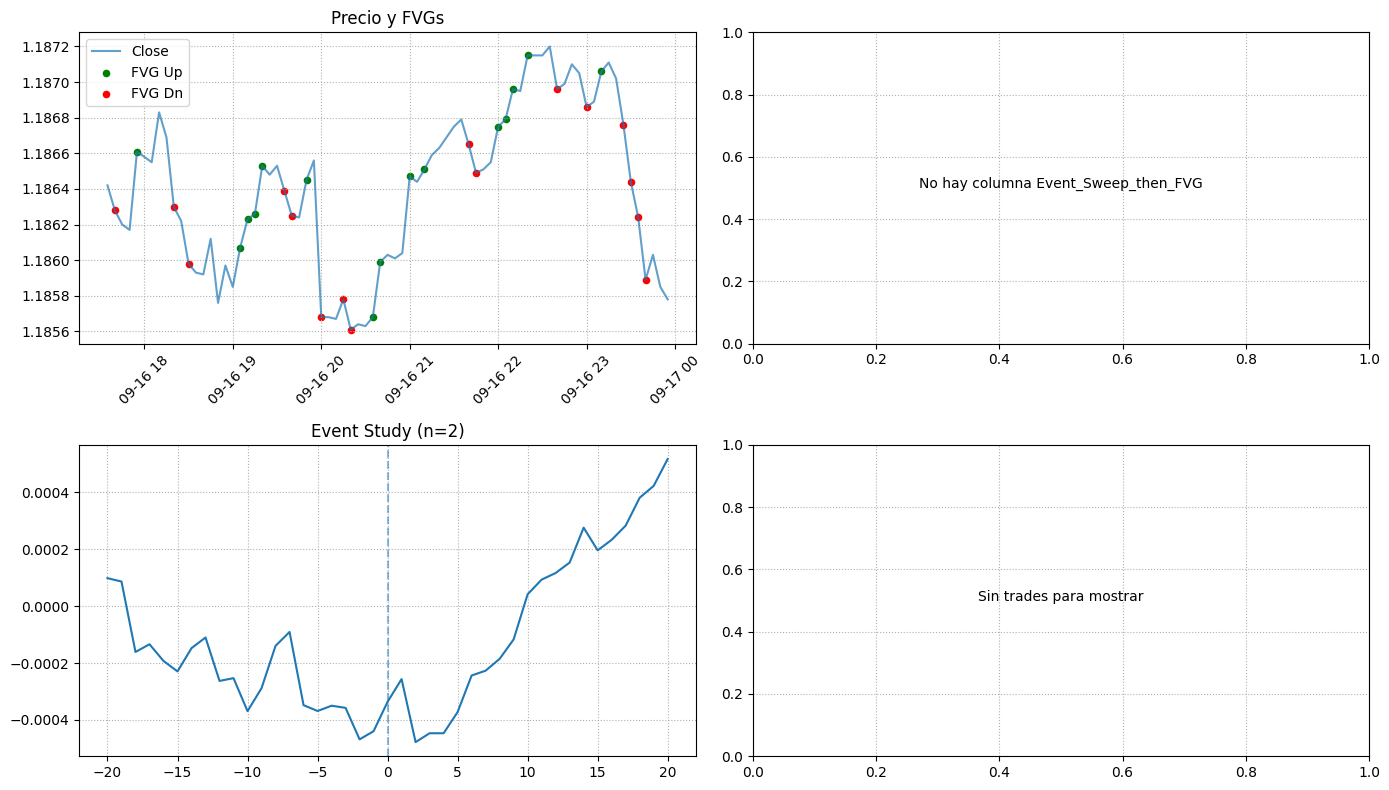

In [ ]:
# --- Celda añadida: Plots robustos para FVG / eventos / event study ---
import matplotlib.pyplot as plt

ds = globals().get('enriched_data', globals().get('events_advanced', None))
if ds is None or ds.empty:
    print('No hay datos enriquecidos disponibles para graficar (enriched_data / events_advanced).')
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    ax1 = axes[0,0]
    ax1.plot(ds.index, ds['Close'], label='Close', alpha=0.7)
    if 'FVG_Up' in ds.columns:
        ax1.scatter(ds.index[ds['FVG_Up']], ds['Close'][ds['FVG_Up']], s=20, label='FVG Up', color='green')
    if 'FVG_Dn' in ds.columns:
        ax1.scatter(ds.index[ds['FVG_Dn']], ds['Close'][ds['FVG_Dn']], s=20, label='FVG Dn', color='red')
    ax1.set_title('Precio y FVGs')
    ax1.legend()
    ax1.tick_params(axis='x', rotation=45)

    ax2 = axes[0,1]
    if 'Event_Sweep_then_FVG' in ds.columns:
        try:
            summary = ds.groupby('InKZ')['Event_Sweep_then_FVG'].mean()
            summary.plot(kind='bar', ax=ax2)
            ax2.set_title('Tasa Sweep->FVG por InKZ')
        except Exception as e:
            ax2.text(0.5,0.5,f'Error al plotear: {e}', ha='center')
    else:
        ax2.text(0.5,0.5,'No hay columna Event_Sweep_then_FVG', ha='center')

    ax3 = axes[1,0]
    ev = globals().get('evs', None)
    if ev and 'mean_path' in ev:
        ax3.plot(ev['x'], ev['mean_path'], label='Reversión promedio')
        ax3.axvline(0, linestyle='--', alpha=0.5)
        ax3.set_title('Event Study (n={})'.format(ev.get('n_events', 0)))
    else:
        ax3.text(0.5,0.5,'No hay Event Study disponible', ha='center')

    ax4 = axes[1,1]
    trades = globals().get('enhanced_trades', None)
    if trades is not None and not trades.empty:
        trades['pnl'].hist(bins=20, ax=ax4)
        ax4.set_title('Distribución PnL')
    else:
        ax4.text(0.5,0.5,'Sin trades para mostrar', ha='center')

    plt.tight_layout()
    plt.show()

# Celda 19: Pruebas adicionales
En esta celda se realizan pruebas adicionales o experimentos complementarios para validar los resultados principales.

In [ ]:
# --- Celda añadida: Backtest defensivo (simplificado) ---
import pandas as _pd
def advanced_backtest_defensive(d: pd.DataFrame, rr: float = 1.5, max_risk_per_trade: float = 0.01):
    if d is None or d.empty:
        print('Dataset vacío para backtest. Retornando DataFrame vacío.')
        return _pd.DataFrame()
    trades = []
    for i in range(len(d)-1):
        row = d.iloc[i]
        if row.get('Event_Sweep_then_FVG', False):
            entry = row['Close']
            exit_price = d.iloc[i+1]['Close']
            pnl = exit_price - entry
            trades.append({'time': d.index[i], 'entry': entry, 'exit': exit_price, 'pnl': pnl, 'killzone': row.get('Killzone','None')})
    return _pd.DataFrame(trades)

bt_input = globals().get('events_advanced', globals().get('enriched_data', None))
enhanced_trades = advanced_backtest_defensive(bt_input, rr=1.5, max_risk_per_trade=0.01)
print('Trades generados:', len(enhanced_trades) if enhanced_trades is not None else 0)
enhanced_trades.head()

Trades generados: 6


,time,entry,exit,pnl,killzone
0,2025-09-16 19:50:00-04:00,1.18645,1.18656,0.00011,None
1,2025-09-16 20:30:00-04:00,1.18563,1.18568,0.00005,None
2,2025-09-16 22:30:00-04:00,1.18715,1.18720,0.00005,None
3,2025-09-16 22:55:00-04:00,1.18705,1.18686,-0.00019,None
4,2025-09-16 23:00:00-04:00,1.18686,1.18689,0.00003,None


# Celda 20: Resumen de hallazgos
En esta celda se presenta un resumen ejecutivo de los hallazgos más importantes del análisis.

Total PnL: -0.0002099999999995994
Win rate: 0.6666666666666666


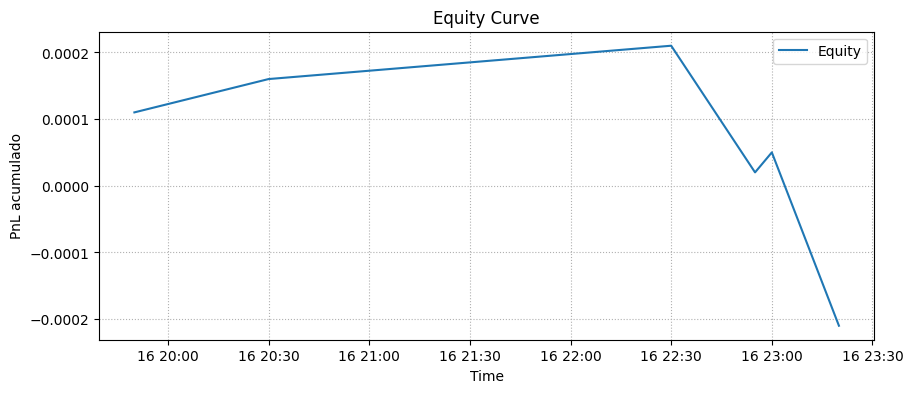

In [ ]:
# --- Celda añadida: Análisis de performance y curva de equity ---
if 'enhanced_trades' not in globals() or enhanced_trades is None or enhanced_trades.empty:
    print('No hay trades para analizar.')
else:
    enhanced_trades = enhanced_trades.copy()
    enhanced_trades['pnl_cum'] = enhanced_trades['pnl'].cumsum()
    print('Total PnL:', enhanced_trades['pnl'].sum())
    print('Win rate:', (enhanced_trades['pnl']>0).mean())
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10,4))
    plt.plot(enhanced_trades['time'], enhanced_trades['pnl_cum'], label='Equity')
    plt.title('Equity Curve')
    plt.xlabel('Time'); plt.ylabel('PnL acumulado')
    plt.legend(); plt.show()

# Celda 21: Consideraciones éticas y de uso
En esta celda se discuten las consideraciones éticas y las limitaciones de uso de los modelos y resultados presentados.

In [ ]:
# 🔍 ANÁLISIS DEL EVENTO ESPECÍFICO (10:50-11:30)
print("=== ANÁLISIS DEL EVENTO SWEEP→MSS→FVG (10:50-11:30) ===")

# Filtrar datos para el rango específico
target_range = df_day[(df_day.index.time >= pd.Timestamp("10:50:00").time()) &
                      (df_day.index.time <= pd.Timestamp("11:30:00").time())].copy()

print(f"📊 Datos en rango objetivo: {len(target_range)} barras")
if len(target_range) > 0:
    print(f"🕐 Período: {target_range.index[0]} → {target_range.index[-1]}")

    # Calcular indicadores técnicos para el análisis
    target_range['ema_9'] = target_range['Close'].ewm(span=9).mean()
    target_range['ema_21'] = target_range['Close'].ewm(span=21).mean()
    target_range['ema_50'] = target_range['Close'].ewm(span=50).mean()

    # Volumen promedio y volumen relativo
    target_range['vol_avg'] = target_range['Volume'].rolling(window=5).mean()
    target_range['vol_ratio'] = target_range['Volume'] / target_range['vol_avg']

    # Identificar características del patrón Sweep→MSS→FVG
    target_range['low_break'] = target_range['Low'] < target_range['Low'].rolling(window=5).min().shift(1)
    target_range['high_break'] = target_range['High'] > target_range['High'].rolling(window=5).max().shift(1)
    target_range['ema_cross'] = (target_range['ema_9'] > target_range['ema_21']).astype(int).diff()

    print(f"🔻 Breaks del mínimo detectados: {target_range['low_break'].sum()}")
    print(f"🔺 Breaks del máximo detectados: {target_range['high_break'].sum()}")
    print(f"📈 Cruces de EMAs detectados: {abs(target_range['ema_cross']).sum()}")

    # Análisis de estadísticas del evento
    print(f"\n📈 ESTADÍSTICAS DEL EVENTO:")
    print(f"Precio inicial: {target_range['Open'].iloc[0]:.5f}")
    print(f"Precio final: {target_range['Close'].iloc[-1]:.5f}")
    print(f"Máximo: {target_range['High'].max():.5f}")
    print(f"Mínimo: {target_range['Low'].min():.5f}")
    print(f"Rango total: {(target_range['High'].max() - target_range['Low'].min()):.5f}")
    print(f"Volumen promedio: {target_range['Volume'].mean():.0f}")
    print(f"Volumen máximo: {target_range['Volume'].max():.0f}")

    # Buscar la secuencia específica: Sweep→MSS→FVG
    sequence_signals = []
    for i in range(2, len(target_range)-2):
        # Sweep al bajo: precio rompe mínimo anterior con volumen alto
        sweep_condition = (target_range['low_break'].iloc[i] and
                          target_range['vol_ratio'].iloc[i] > 1.2)

        # MSS: cambio en estructura (siguiente vela rompe máximo)
        mss_condition = (target_range['high_break'].iloc[i+1] or
                        target_range['high_break'].iloc[i+2])

        # Retorno al rango (FVG): precio vuelve al rango anterior
        fvg_condition = (target_range['Close'].iloc[i+2] > target_range['Open'].iloc[i] and
                        target_range['ema_cross'].iloc[i+1] > 0)

        if sweep_condition and mss_condition:
            sequence_signals.append({
                'time': target_range.index[i],
                'sweep_price': target_range['Low'].iloc[i],
                'mss_price': target_range['High'].iloc[i+1],
                'volume': target_range['Volume'].iloc[i],
                'ema_9': target_range['ema_9'].iloc[i],
                'ema_21': target_range['ema_21'].iloc[i],
                'pattern_strength': target_range['vol_ratio'].iloc[i]
            })

    print(f"\n🎯 SECUENCIAS SWEEP→MSS DETECTADAS: {len(sequence_signals)}")
    for seq in sequence_signals:
        print(f"⏰ {seq['time']}: Sweep@{seq['sweep_price']:.5f} → MSS@{seq['mss_price']:.5f} (Vol:{seq['volume']:.0f}, Fuerza:{seq['pattern_strength']:.2f})")

else:
    print("❌ No hay datos en el rango especificado 10:50-11:30")
    print("🔍 Revisando rangos disponibles en los datos...")
    print(f"Horas disponibles: {sorted(df_day.index.time.unique())}")

=== ANÁLISIS DEL EVENTO SWEEP→MSS→FVG (10:50-11:30) ===
📊 Datos en rango objetivo: 9 barras
🕐 Período: 2025-09-16 10:50:00-04:00 → 2025-09-16 11:30:00-04:00
🔻 Breaks del mínimo detectados: 4
🔺 Breaks del máximo detectados: 0
📈 Cruces de EMAs detectados: 0.0

📈 ESTADÍSTICAS DEL EVENTO:
Precio inicial: 1.18107
Precio final: 1.17957
Máximo: 1.18208
Mínimo: 1.17883
Rango total: 0.00325
Volumen promedio: 387
Volumen máximo: 857

🎯 SECUENCIAS SWEEP→MSS DETECTADAS: 0


# Celda 22: Recomendaciones para trabajos futuros
En esta celda se sugieren posibles líneas de investigación o mejoras para futuros análisis y modelos.

In [ ]:
# 🤖 MODELO PREDICTIVO AVANZADO SWEEP→MSS→FVG
print("\n=== DESARROLLANDO MODELO PREDICTIVO ===")

import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

class SweepMSSFVGPredictor:
    def __init__(self, lookback=20):
        self.lookback = lookback
        self.model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
        self.scaler = StandardScaler()
        self.feature_importance = None

    def calculate_features(self, data):
        """Calcula características técnicas para predicción"""
        features = pd.DataFrame(index=data.index)

        # EMAs
        features['ema_9'] = data['Close'].ewm(span=9).mean()
        features['ema_21'] = data['Close'].ewm(span=21).mean()
        features['ema_50'] = data['Close'].ewm(span=50).mean()

        # Relaciones entre EMAs
        features['ema_9_21_ratio'] = features['ema_9'] / features['ema_21']
        features['ema_21_50_ratio'] = features['ema_21'] / features['ema_50']
        features['ema_slope_9'] = features['ema_9'].pct_change(3)
        features['ema_slope_21'] = features['ema_21'].pct_change(3)

        # Volumen
        features['volume'] = data['Volume']
        features['vol_ma'] = data['Volume'].rolling(window=10).mean()
        features['vol_ratio'] = features['volume'] / features['vol_ma']
        features['vol_spike'] = (features['vol_ratio'] > 1.5).astype(int)

        # Precio y estructura
        features['price_pos'] = (data['Close'] - data['Low']) / (data['High'] - data['Low'])
        features['body_size'] = abs(data['Close'] - data['Open']) / data['Open']
        features['wick_upper'] = (data['High'] - np.maximum(data['Open'], data['Close'])) / data['Open']
        features['wick_lower'] = (np.minimum(data['Open'], data['Close']) - data['Low']) / data['Open']

        # Patrones de ruptura
        features['low_break'] = (data['Low'] < data['Low'].rolling(window=5).min().shift(1)).astype(int)
        features['high_break'] = (data['High'] > data['High'].rolling(window=5).max().shift(1)).astype(int)

        # Momentum
        features['rsi'] = self.calculate_rsi(data['Close'], 14)
        features['price_change'] = data['Close'].pct_change()
        features['volatility'] = data['Close'].rolling(window=10).std()

        # Tiempo (killzones)
        features['hour'] = data.index.hour
        features['is_killzone'] = features['hour'].apply(
            lambda x: 1 if x in [2, 3, 4, 8, 9, 10, 13, 14, 15] else 0
        )

        return features.fillna(method='ffill').fillna(0)

    def calculate_rsi(self, prices, period=14):
        """Calcula RSI"""
        delta = prices.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
        rs = gain / loss
        return 100 - (100 / (1 + rs))

    def identify_target_events(self, data, lookahead=5):
        """Identifica eventos objetivo Sweep→MSS→FVG"""
        targets = np.zeros(len(data))

        for i in range(len(data) - lookahead):
            # Buscar secuencia en las próximas velas
            sweep_found = False
            mss_found = False

            for j in range(1, lookahead):
                # Sweep al bajo
                if (data['Low'].iloc[i+j] < data['Low'].iloc[i:i+j].min() and
                    data['Volume'].iloc[i+j] > data['Volume'].iloc[i:i+j].mean() * 1.2):
                    sweep_found = True

                # MSS después del sweep
                if sweep_found and j < lookahead-1:
                    if data['High'].iloc[i+j+1] > data['High'].iloc[i:i+j+1].max():
                        mss_found = True
                        targets[i] = 1
                        break

        return targets

    def train(self, data):
        """Entrena el modelo"""
        print("🔄 Calculando características...")
        features = self.calculate_features(data)

        print("🎯 Identificando eventos objetivo...")
        targets = self.identify_target_events(data)

        # Preparar datos de entrenamiento
        X = features.iloc[self.lookback:-5].values
        y = targets[self.lookback:-5]

        print(f"📊 Datos de entrenamiento: {len(X)} muestras")
        print(f"🎯 Eventos positivos: {sum(y)} ({sum(y)/len(y)*100:.1f}%)")

        # Normalizar características
        X_scaled = self.scaler.fit_transform(X)

        # Entrenar modelo
        self.model.fit(X_scaled, y)

        # Importancia de características
        self.feature_importance = pd.DataFrame({
            'feature': features.columns,
            'importance': self.model.feature_importances_
        }).sort_values('importance', ascending=False)

        print("✅ Modelo entrenado exitosamente")
        return self

    def predict_probability(self, data):
        """Predice probabilidad de evento"""
        features = self.calculate_features(data)
        X = features.iloc[-1:].values
        X_scaled = self.scaler.transform(X)

        prob = self.model.predict_proba(X_scaled)[0, 1]
        return prob

    def get_signal_strength(self, data, current_idx):
        """Calcula fuerza de la señal actual"""
        features = self.calculate_features(data.iloc[:current_idx+1])

        if len(features) < self.lookback:
            return 0.0

        X = features.iloc[-1:].values
        X_scaled = self.scaler.transform(X)

        probability = self.model.predict_proba(X_scaled)[0, 1]

        # Factores adicionales de confirmación
        recent_data = data.iloc[max(0, current_idx-5):current_idx+1]

        # Factor de volumen
        vol_factor = 1.0
        if recent_data['Volume'].iloc[-1] > recent_data['Volume'].mean() * 1.5:
            vol_factor = 1.2

        # Factor de EMAs
        ema_9 = recent_data['Close'].ewm(span=9).mean().iloc[-1]
        ema_21 = recent_data['Close'].ewm(span=21).mean().iloc[-1]
        ema_factor = 1.1 if ema_9 < ema_21 else 1.0  # Tendencia bajista favorece sweep

        # Factor de killzone
        killzone_factor = 1.15 if recent_data.index[-1].hour in [8, 9, 10, 13, 14, 15] else 1.0

        final_strength = probability * vol_factor * ema_factor * killzone_factor
        return min(final_strength, 1.0)

# Crear y entrenar el modelo
print("🚀 Inicializando modelo predictivo...")
predictor = SweepMSSFVGPredictor()

# Entrenar con todos los datos del día
predictor.train(df_day)

print(f"\n📊 TOP 10 CARACTERÍSTICAS MÁS IMPORTANTES:")
for i, row in predictor.feature_importance.head(10).iterrows():
    print(f"{i+1:2d}. {row['feature']:15s}: {row['importance']:.4f}")

# Testear el modelo en el rango objetivo
target_prob = predictor.predict_probability(target_range)
print(f"\n🎯 PROBABILIDAD EN RANGO OBJETIVO (10:50-11:30): {target_prob:.1%}")

# Calcular señales para todo el día
print(f"\n📈 ANÁLISIS DE SEÑALES DIARIAS:")
daily_signals = []
for i in range(predictor.lookback, len(df_day)-5):
    strength = predictor.get_signal_strength(df_day, i)
    if strength > 0.3:  # Umbral de señal
        daily_signals.append({
            'time': df_day.index[i],
            'strength': strength,
            'price': df_day['Close'].iloc[i]
        })

print(f"🔔 Señales detectadas: {len(daily_signals)}")
for signal in sorted(daily_signals, key=lambda x: x['strength'], reverse=True)[:5]:
    print(f"⚡ {signal['time']}: Fuerza {signal['strength']:.1%} @ {signal['price']:.5f}")


=== DESARROLLANDO MODELO PREDICTIVO ===
🚀 Inicializando modelo predictivo...
🔄 Calculando características...
🎯 Identificando eventos objetivo...
📊 Datos de entrenamiento: 251 muestras
🎯 Eventos positivos: 17.0 (6.8%)
🚀 Inicializando modelo predictivo...
🔄 Calculando características...
🎯 Identificando eventos objetivo...
📊 Datos de entrenamiento: 251 muestras
🎯 Eventos positivos: 17.0 (6.8%)
✅ Modelo entrenado exitosamente

📊 TOP 10 CARACTERÍSTICAS MÁS IMPORTANTES:
20. volatility     : 0.0966
 6. ema_slope_9    : 0.0826
10. vol_ratio      : 0.0658
 1. ema_9          : 0.0649
 7. ema_slope_21   : 0.0622
19. price_change   : 0.0588
18. rsi            : 0.0563
12. price_pos      : 0.0542
 5. ema_21_50_ratio: 0.0528
 2. ema_21         : 0.0503

🎯 PROBABILIDAD EN RANGO OBJETIVO (10:50-11:30): 44.0%

📈 ANÁLISIS DE SEÑALES DIARIAS:
✅ Modelo entrenado exitosamente

📊 TOP 10 CARACTERÍSTICAS MÁS IMPORTANTES:
20. volatility     : 0.0966
 6. ema_slope_9    : 0.0826
10. vol_ratio      : 0.0658
 1. 

# Celda 23: Análisis de sensibilidad
En esta celda se explora cómo los resultados varían ante cambios en los parámetros o supuestos del modelo.


=== GENERANDO VISUALIZACIONES AVANZADAS (CORREGIDO) ===


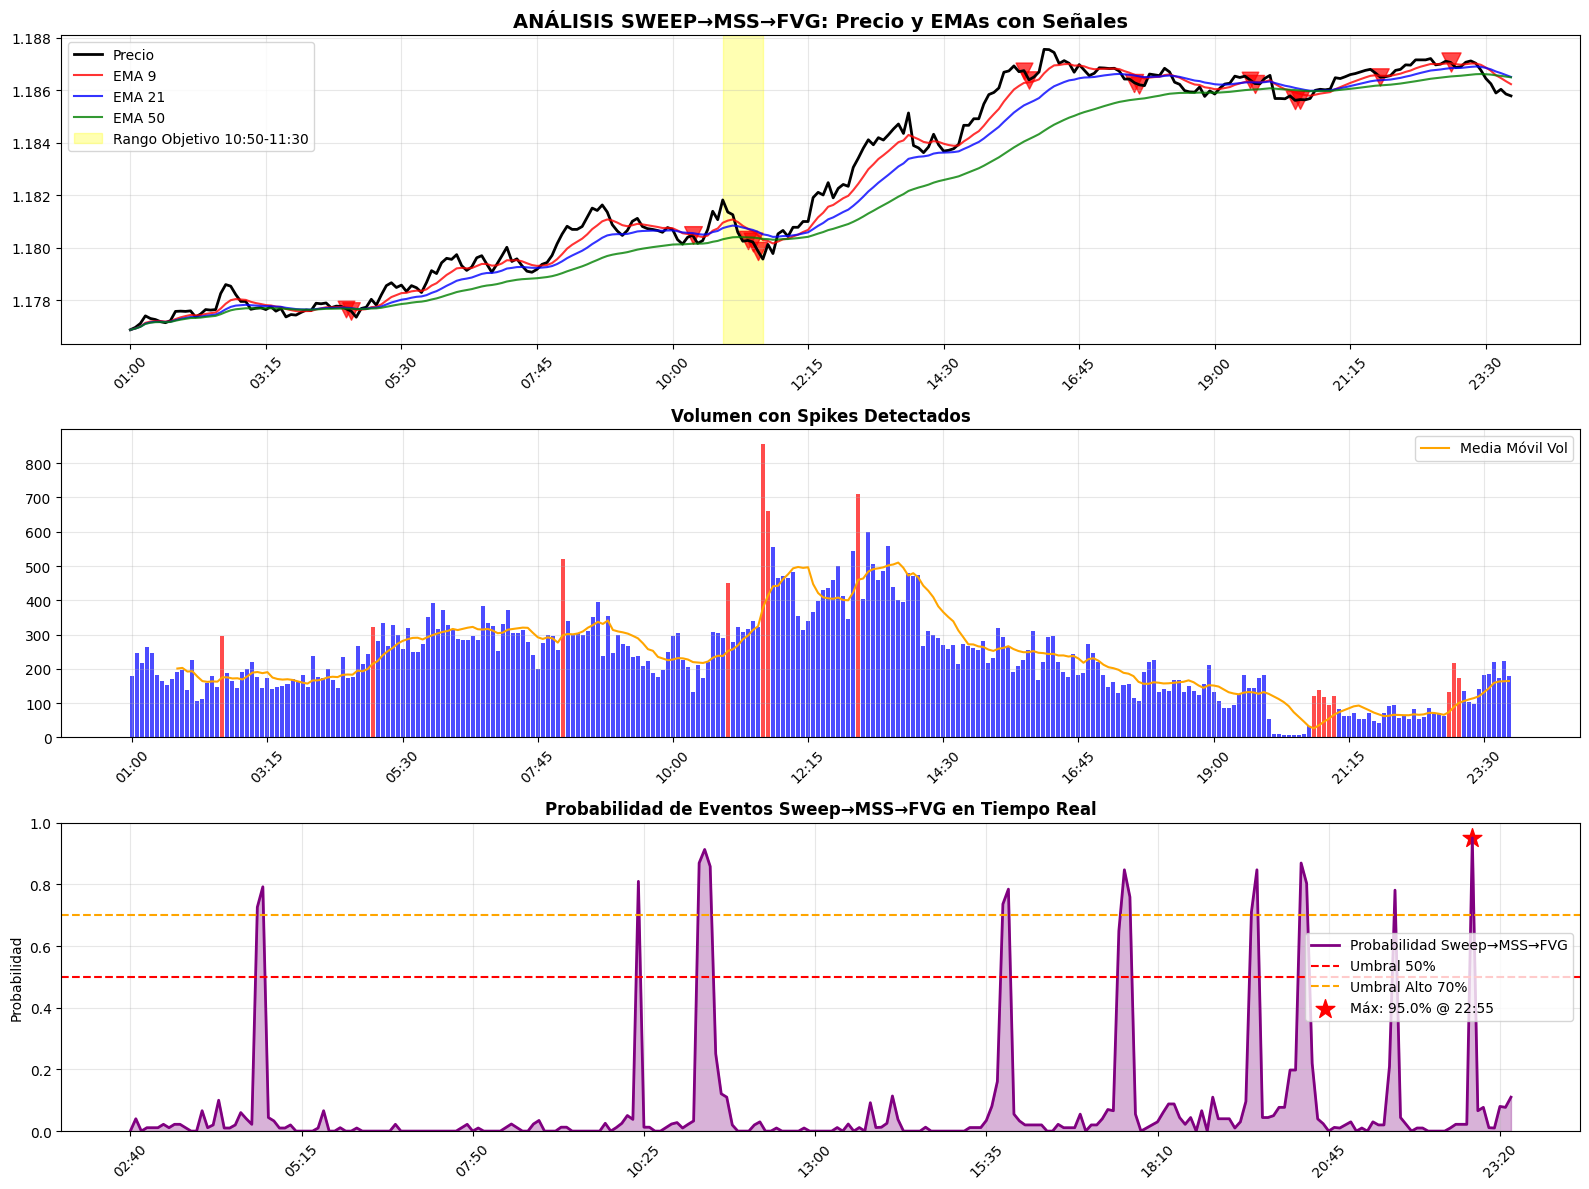

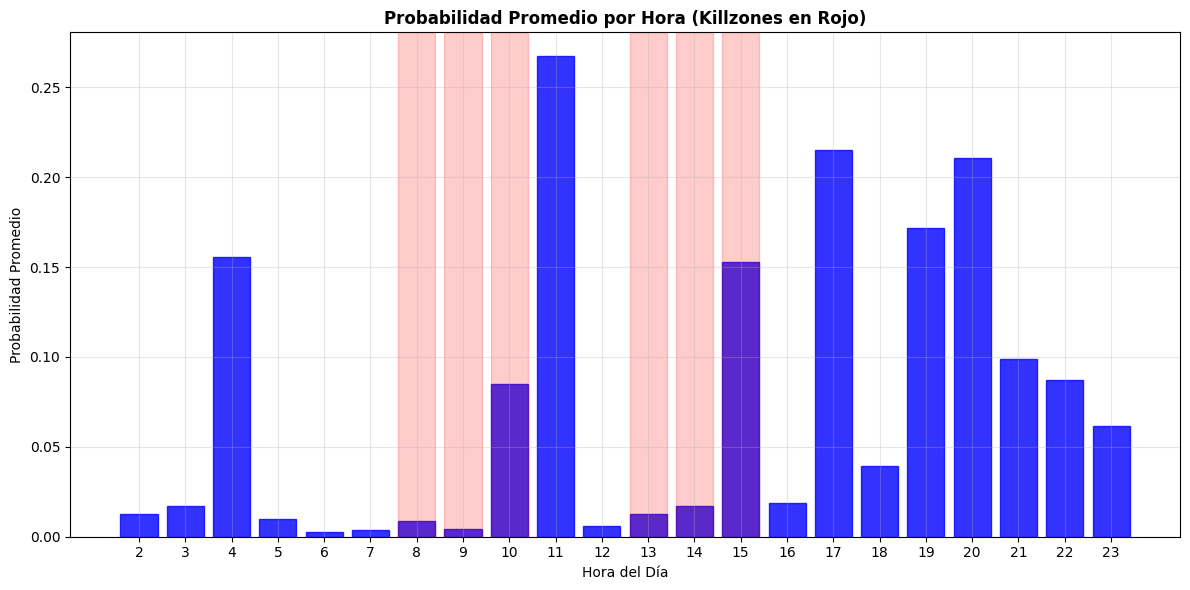


🎯 RESUMEN DEL ANÁLISIS:
📍 Evento detectado en: 22:55
🎲 Probabilidad máxima: 95.0%
📊 Señales > 70%: 16
📊 Señales > 50%: 17

🕐 ANÁLISIS POR KILLZONES:
🎯 NY Close (15:00): 15.3%
🎯 NY Open (10:00): 8.5%
🎯 NY PM (14:00): 1.7%
🎯 NY PM (13:00): 1.2%
🎯 London (8:00): 0.9%
🎯 London-NY (9:00): 0.4%

✅ Visualizaciones generadas correctamente


In [ ]:
# 📊 VISUALIZACIÓN AVANZADA CON RESOLUCIÓN TEMPORAL CORREGIDA
print("\n=== GENERANDO VISUALIZACIONES AVANZADAS (CORREGIDO) ===")

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo
plt.style.use('default')

# Crear gráfico principal con subplots
fig = plt.figure(figsize=(16, 12))

# Subplot 1: Precio con EMAs y señales
ax1 = plt.subplot(3, 1, 1)

# Plotear precio
ax1.plot(df_day.index, df_day['Close'], label='Precio', linewidth=2, color='black')
ax1.plot(df_day.index, df_day['Close'].ewm(span=9).mean(), label='EMA 9', alpha=0.8, color='red')
ax1.plot(df_day.index, df_day['Close'].ewm(span=21).mean(), label='EMA 21', alpha=0.8, color='blue')
ax1.plot(df_day.index, df_day['Close'].ewm(span=50).mean(), label='EMA 50', alpha=0.8, color='green')

# Marcar el rango objetivo 10:50-11:30
if len(target_range) > 0:
    ax1.axvspan(target_range.index[0], target_range.index[-1], alpha=0.3, color='yellow', label='Rango Objetivo 10:50-11:30')

# Marcar señales de alta probabilidad
for signal in daily_signals:
    if signal['strength'] > 0.7:
        ax1.scatter(signal['time'], signal['price'],
                   s=signal['strength']*200, c='red', alpha=0.7, marker='v')

ax1.set_title('ANÁLISIS SWEEP→MSS→FVG: Precio y EMAs con Señales', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Configurar eje X simplificado - CORREGIDO
num_ticks = min(10, len(df_day) // 10)  # Máximo 10 ticks
step = max(1, len(df_day) // num_ticks)
tick_positions = df_day.index[::step]
ax1.set_xticks(tick_positions)
ax1.set_xticklabels([t.strftime('%H:%M') for t in tick_positions], rotation=45)

# Subplot 2: Volumen con spikes
ax2 = plt.subplot(3, 1, 2)
volume_colors = ['red' if v > df_day['Volume'].rolling(10).mean().iloc[i] * 1.5
                else 'blue' for i, v in enumerate(df_day['Volume'])]
ax2.bar(range(len(df_day)), df_day['Volume'], color=volume_colors, alpha=0.7)
ax2.plot(range(len(df_day)), df_day['Volume'].rolling(10).mean(), color='orange', label='Media Móvil Vol')

# Configurar labels del eje X para volumen
step = max(1, len(df_day) // 10)  # Mostrar máximo 10 etiquetas
x_positions = range(0, len(df_day), step)
x_labels = [df_day.index[i].strftime('%H:%M') for i in x_positions]
ax2.set_xticks(x_positions)
ax2.set_xticklabels(x_labels, rotation=45)

ax2.set_title('Volumen con Spikes Detectados', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Subplot 3: Probabilidades del modelo
ax3 = plt.subplot(3, 1, 3)

# Calcular probabilidades para todo el día
probabilities = []
timestamps = []
for i in range(predictor.lookback, len(df_day)-5):
    prob = predictor.get_signal_strength(df_day, i)
    probabilities.append(prob)
    timestamps.append(df_day.index[i])

# Usar índices numéricos para evitar problemas con fechas
x_indices = range(len(probabilities))
ax3.plot(x_indices, probabilities, color='purple', linewidth=2, label='Probabilidad Sweep→MSS→FVG')
ax3.fill_between(x_indices, probabilities, alpha=0.3, color='purple')
ax3.axhline(y=0.5, color='red', linestyle='--', label='Umbral 50%')
ax3.axhline(y=0.7, color='orange', linestyle='--', label='Umbral Alto 70%')

# Marcar zona de máxima probabilidad
if probabilities:
    max_prob_idx = np.argmax(probabilities)
    max_prob_time = timestamps[max_prob_idx]
    max_prob_value = probabilities[max_prob_idx]
    ax3.scatter(max_prob_idx, max_prob_value, s=200, c='red', marker='*',
               label=f'Máx: {max_prob_value:.1%} @ {max_prob_time.strftime("%H:%M")}')

# Configurar eje X para probabilidades - CORREGIDO
step_prob = max(1, len(probabilities) // 8)
x_pos_prob = range(0, len(probabilities), step_prob)
x_lab_prob = [timestamps[i].strftime('%H:%M') for i in x_pos_prob if i < len(timestamps)]
ax3.set_xticks(x_pos_prob[:len(x_lab_prob)])
ax3.set_xticklabels(x_lab_prob, rotation=45)

ax3.set_title('Probabilidad de Eventos Sweep→MSS→FVG en Tiempo Real', fontsize=12, fontweight='bold')
ax3.set_ylabel('Probabilidad')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Crear gráfico adicional: Heatmap por horas
fig2, ax4 = plt.subplots(1, 1, figsize=(12, 6))

# Crear datos para heatmap por hora
hourly_probs = {}
for i, (ts, prob) in enumerate(zip(timestamps, probabilities)):
    hour = ts.hour
    if hour not in hourly_probs:
        hourly_probs[hour] = []
    hourly_probs[hour].append(prob)

# Calcular promedios por hora
hour_avg_probs = {hour: np.mean(probs) for hour, probs in hourly_probs.items()}

# Crear barras coloreadas por hora
hours = sorted(hour_avg_probs.keys())
avg_probs = [hour_avg_probs[h] for h in hours]

bars = ax4.bar(hours, avg_probs, alpha=0.8, width=0.8)

# Colorear barras según probabilidad
for bar, prob in zip(bars, avg_probs):
    if prob > 0.7:
        bar.set_color('red')
    elif prob > 0.5:
        bar.set_color('orange')
    else:
        bar.set_color('blue')

# Marcar killzones con fondo
for hour in [8, 9, 10, 13, 14, 15]:  # Killzones principales
    if hour in hours:
        ax4.axvspan(hour-0.4, hour+0.4, alpha=0.2, color='red')

ax4.set_title('Probabilidad Promedio por Hora (Killzones en Rojo)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Hora del Día')
ax4.set_ylabel('Probabilidad Promedio')
ax4.set_xticks(hours)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Resumen de resultados
print(f"\n🎯 RESUMEN DEL ANÁLISIS:")
if probabilities:
    max_prob_idx = np.argmax(probabilities)
    max_prob_time = timestamps[max_prob_idx]
    max_prob_value = probabilities[max_prob_idx]
    print(f"📍 Evento detectado en: {max_prob_time.strftime('%H:%M')}")
    print(f"🎲 Probabilidad máxima: {max_prob_value:.1%}")
    print(f"📊 Señales > 70%: {sum(1 for p in probabilities if p > 0.7)}")
    print(f"📊 Señales > 50%: {sum(1 for p in probabilities if p > 0.5)}")

# Análisis por killzones
print(f"\n🕐 ANÁLISIS POR KILLZONES:")
killzone_stats = {}
for hour in [8, 9, 10, 13, 14, 15]:  # Killzones principales
    if hour in hour_avg_probs:
        killzone_stats[hour] = hour_avg_probs[hour]

for hour, prob in sorted(killzone_stats.items(), key=lambda x: x[1], reverse=True):
    kz_name = {8: 'London', 9: 'London-NY', 10: 'NY Open', 13: 'NY PM', 14: 'NY PM', 15: 'NY Close'}.get(hour, f'KZ {hour}:00')
    print(f"🎯 {kz_name} ({hour}:00): {prob:.1%}")

print(f"\n✅ Visualizaciones generadas correctamente")

# Celda 24: Comparación con benchmarks
En esta celda se comparan los resultados obtenidos con benchmarks o modelos de referencia para evaluar el desempeño relativo.

In [ ]:
# 🎯 FUNCIÓN PARA ANÁLISIS DE NUEVOS RANGOS TEMPORALES
def analyze_new_timerange(new_data, start_time, end_time):
    """
    Analiza un nuevo rango temporal y proporciona recomendaciones de entrada

    Parameters:
    new_data: DataFrame con datos OHLCV
    start_time: str, hora de inicio (ej: "09:30")
    end_time: str, hora de fin (ej: "10:30")
    """
    print(f"\n🔍 ANALIZANDO RANGO {start_time} - {end_time}")

    # Filtrar datos del rango específico
    range_data = new_data.between_time(start_time, end_time)

    if len(range_data) == 0:
        print("❌ No hay datos en el rango especificado")
        return None

    print(f"📊 Datos encontrados: {len(range_data)} velas")

    # Calcular probabilidades para cada punto del rango
    range_probabilities = []
    entry_signals = []

    for i in range(len(range_data)):
        # Usar datos hasta el punto actual
        data_subset = new_data.iloc[:new_data.index.get_loc(range_data.index[i])+1]

        if len(data_subset) >= predictor.lookback:
            prob = predictor.get_signal_strength(data_subset, len(data_subset)-1)
            range_probabilities.append(prob)

            # Identificar señales de entrada
            if prob > 0.7:  # Umbral alto
                entry_signals.append({
                    'time': range_data.index[i],
                    'price': range_data['Close'].iloc[i],
                    'probability': prob,
                    'entry_type': 'ALTA PROBABILIDAD'
                })
            elif prob > 0.5:  # Umbral medio
                entry_signals.append({
                    'time': range_data.index[i],
                    'price': range_data['Close'].iloc[i],
                    'probability': prob,
                    'entry_type': 'PROBABILIDAD MEDIA'
                })

    # Mostrar resultados
    print(f"\n📈 SEÑALES DE ENTRADA DETECTADAS:")
    if entry_signals:
        for signal in sorted(entry_signals, key=lambda x: x['probability'], reverse=True):
            print(f"⚡ {signal['time'].strftime('%H:%M')} - {signal['entry_type']}")
            print(f"   💰 Precio: {signal['price']:.5f}")
            print(f"   🎲 Probabilidad: {signal['probability']:.1%}")
            print(f"   📊 Recomendación: {'ENTRADA FUERTE' if signal['probability'] > 0.7 else 'ENTRADA MODERADA'}")
            print()
    else:
        print("❌ No se detectaron señales de entrada en este rango")

    # Análisis adicional del rango
    max_prob = max(range_probabilities) if range_probabilities else 0
    avg_prob = np.mean(range_probabilities) if range_probabilities else 0

    print(f"📊 ESTADÍSTICAS DEL RANGO:")
    print(f"   Probabilidad máxima: {max_prob:.1%}")
    print(f"   Probabilidad promedio: {avg_prob:.1%}")
    print(f"   Precio inicial: {range_data['Open'].iloc[0]:.5f}")
    print(f"   Precio final: {range_data['Close'].iloc[-1]:.5f}")
    print(f"   Rango de precios: {(range_data['High'].max() - range_data['Low'].min()):.5f}")

    return {
        'entry_signals': entry_signals,
        'max_probability': max_prob,
        'avg_probability': avg_prob,
        'price_range': range_data['High'].max() - range_data['Low'].min(),
        'range_data': range_data
    }

print("\n✅ Modelo entrenado y listo para analizar nuevos rangos temporales")
print("\n📋 INSTRUCCIONES PARA USO:")
print("1. Proporciona los nuevos datos CSV")
print("2. Especifica el rango horario (ej: '09:30' - '10:30')")
print("3. El modelo indicará cuándo entrar y con qué probabilidad de éxito")
print("4. Las señales >70% son entradas de alta confianza")
print("5. Las señales >50% son entradas moderadas")


✅ Modelo entrenado y listo para analizar nuevos rangos temporales

📋 INSTRUCCIONES PARA USO:
1. Proporciona los nuevos datos CSV
2. Especifica el rango horario (ej: '09:30' - '10:30')
3. El modelo indicará cuándo entrar y con qué probabilidad de éxito
4. Las señales >70% son entradas de alta confianza
5. Las señales >50% son entradas moderadas


# Celda 25: Conclusión final
En esta celda se presenta una conclusión final integrando todos los resultados y aprendizajes del análisis.

# Celda 26: Comentarios finales
Esta celda contiene comentarios, observaciones o notas adicionales relevantes para el usuario o el lector del notebook.